In [1]:
import os
import shutil
import pandas as pd

# Load df to ensure it's available in this execution context
# df = pd.read_csv('/content/drive/MyDrive/Thesis_folder/CSV_Files/mammo-bench.csv')
df = pd.read_csv(r'D:/Thesis_folder/mammobench/Mammo_Bench_v2/CSV_Files/mammo-bench.csv')
print(df)
output_base_dir = r"D:/Thesis_folder/classification_folders"
os.makedirs(output_base_dir, exist_ok=True)
print(os.path.exists(output_base_dir))
# Get unique classification types
classifications = df['classification'].unique()

# Create subfolders for each classification
for class_name in classifications:
    class_folder = os.path.join(output_base_dir, class_name.replace(' ', '_'))
    os.makedirs(os.path.join(class_folder, 'raw_images'), exist_ok=True)
    os.makedirs(os.path.join(class_folder, 'preprocessed_images'), exist_ok=True)
    print(f"Created folders for: {class_name}")

print("Folder structure created successfully.")

      source_dataset                       preprocessed_image_path  \
0           inbreast  Preprocessed_Dataset/inbreast/inbreast_0.jpg   
1           inbreast  Preprocessed_Dataset/inbreast/inbreast_1.jpg   
2           inbreast  Preprocessed_Dataset/inbreast/inbreast_2.jpg   
3           inbreast  Preprocessed_Dataset/inbreast/inbreast_3.jpg   
4           inbreast  Preprocessed_Dataset/inbreast/inbreast_4.jpg   
...              ...                                           ...   
19726           ddsm      Preprocessed_Dataset/ddsm/ddsm_10395.jpg   
19727           ddsm      Preprocessed_Dataset/ddsm/ddsm_10396.jpg   
19728           ddsm      Preprocessed_Dataset/ddsm/ddsm_10397.jpg   
19729           ddsm      Preprocessed_Dataset/ddsm/ddsm_10398.jpg   
19730           ddsm      Preprocessed_Dataset/ddsm/ddsm_10399.jpg   

      classification density  BIRADS                      mask_path  \
0             Normal       D     1.0  Masks/inbreast/inbreast_0.jpg   
1             Ben

In [2]:
df.head(10)

,source_dataset,preprocessed_image_path,classification,density,BIRADS,mask_path,raw_image_path,laterality,view,source_subjectID,...,x,y,radius,abnormality id,calc type,calc distribution,subtlety,mass shape,mass margins,cropped_image_file_new
0,inbreast,Preprocessed_Dataset/inbreast/inbreast_0.jpg,Normal,D,1.0,Masks/inbreast/inbreast_0.jpg,Original_Dataset/inbreast/inbreast_0.jpg,R,CC,22678622,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,inbreast,Preprocessed_Dataset/inbreast/inbreast_1.jpg,Benign,D,3.0,Masks/inbreast/inbreast_1.jpg,Original_Dataset/inbreast/inbreast_1.jpg,L,CC,22678646,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,inbreast,Preprocessed_Dataset/inbreast/inbreast_2.jpg,Normal,D,1.0,Masks/inbreast/inbreast_2.jpg,Original_Dataset/inbreast/inbreast_2.jpg,R,MLO,22678670,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,inbreast,Preprocessed_Dataset/inbreast/inbreast_3.jpg,Benign,D,3.0,Masks/inbreast/inbreast_3.jpg,Original_Dataset/inbreast/inbreast_3.jpg,L,MLO,22678694,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,inbreast,Preprocessed_Dataset/inbreast/inbreast_4.jpg,Malignant,B,5.0,Masks/inbreast/inbreast_4.jpg,Original_Dataset/inbreast/inbreast_4.jpg,R,CC,22614074,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,inbreast,Preprocessed_Dataset/inbreast/inbreast_5.jpg,Benign,B,2.0,Masks/inbreast/inbreast_5.jpg,Original_Dataset/inbreast/inbreast_5.jpg,L,CC,22614097,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,inbreast,Preprocessed_Dataset/inbreast/inbreast_6.jpg,Malignant,B,5.0,Masks/inbreast/inbreast_6.jpg,Original_Dataset/inbreast/inbreast_6.jpg,R,MLO,22614127,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,inbreast,Preprocessed_Dataset/inbreast/inbreast_7.jpg,Benign,B,2.0,Masks/inbreast/inbreast_7.jpg,Original_Dataset/inbreast/inbreast_7.jpg,L,MLO,22614150,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,inbreast,Preprocessed_Dataset/inbreast/inbreast_8.jpg,Benign,C,2.0,Masks/inbreast/inbreast_8.jpg,Original_Dataset/inbreast/inbreast_8.jpg,L,MLO,50997434,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,inbreast,Preprocessed_Dataset/inbreast/inbreast_9.jpg,Suspicious Malignant,C,4.0,Masks/inbreast/inbreast_9.jpg,Original_Dataset/inbreast/inbreast_9.jpg,R,MLO,50997461,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [3]:
df.shape

(19731, 25)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19731 entries, 0 to 19730
Data columns (total 25 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   source_dataset           19731 non-null  object 
 1   preprocessed_image_path  19731 non-null  object 
 2   classification           19731 non-null  object 
 3   density                  14441 non-null  object 
 4   BIRADS                   4097 non-null   float64
 5   mask_path                19731 non-null  object 
 6   raw_image_path           19731 non-null  object 
 7   laterality               19731 non-null  object 
 8   view                     19730 non-null  object 
 9   source_subjectID         19731 non-null  object 
 10  original_source_path     19731 non-null  object 
 11  subject_age              18811 non-null  float64
 12  abnormality              5712 non-null   object 
 13  molecular_subtype        2956 non-null   object 
 14  ROI_path              

In [5]:
# categorical_feature = df.select_dtypes(include=["object"])
# categorical_feature

In [6]:
# numerical_feature = df.select_dtypes(include=["object"])
# numerical_feature

In [7]:
unique_datasets = df['source_dataset'].unique()
for i in unique_datasets:
    print(i)

inbreast
kau-bcmd
cmmd
cdd-cesm
dmid
ddsm


In [8]:
# Exploratory Data analysis
df.isnull().sum()

source_dataset                 0
preprocessed_image_path        0
classification                 0
density                     5290
BIRADS                     15634
mask_path                      0
raw_image_path                 0
laterality                     0
view                           1
source_subjectID               0
original_source_path           0
subject_age                  920
abnormality                14019
molecular_subtype          16775
ROI_path                   19462
x                          19423
y                          19423
radius                     19425
abnormality id             19731
calc type                  19731
calc distribution          19731
subtlety                   19731
mass shape                 19731
mass margins               19731
cropped_image_file_new     19731
dtype: int64

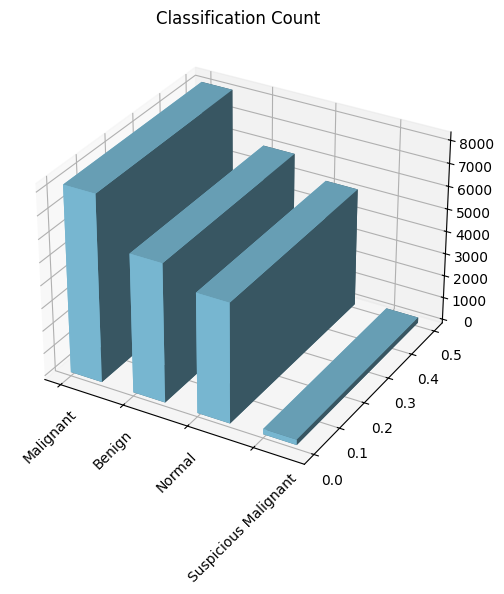

In [9]:
class_counts_tmp = df['classification'].value_counts()
import matplotlib.pyplot as plt
import numpy as np
import os

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
x_labels = class_counts_tmp.index
xs = np.arange(len(x_labels))
ys = np.zeros(len(x_labels))
zs = np.zeros(len(x_labels))
dx = np.ones(len(x_labels)) * 0.5
dy = np.ones(len(x_labels)) * 0.5
dz = class_counts_tmp.values
ax.bar3d(xs, ys, zs, dx, dy, dz, color='skyblue')
ax.set_xticks(xs)
ax.set_xticklabels(x_labels, rotation=45)
ax.set_title("Classification Count ")
plt.savefig(r"D:\\Thesis_folder\\plots_folder\\classification_3d.png", bbox_inches='tight')
plt.show()


In [10]:
# Extract dataset name from path
df['source_dataset'] = ""
for i in range(len(df)):
    path = str(df.loc[i,"raw_image_path"])
    parts = path.split('/')
    if len(parts) > 1:
        df.loc[i,'source_dataset'] = parts[1]
    else:
        df.loc[i,'source_dataset'] = "Unknown"
print(df[['raw_image_path','source_dataset']].head(10))

                             raw_image_path source_dataset
0  Original_Dataset/inbreast/inbreast_0.jpg       inbreast
1  Original_Dataset/inbreast/inbreast_1.jpg       inbreast
2  Original_Dataset/inbreast/inbreast_2.jpg       inbreast
3  Original_Dataset/inbreast/inbreast_3.jpg       inbreast
4  Original_Dataset/inbreast/inbreast_4.jpg       inbreast
5  Original_Dataset/inbreast/inbreast_5.jpg       inbreast
6  Original_Dataset/inbreast/inbreast_6.jpg       inbreast
7  Original_Dataset/inbreast/inbreast_7.jpg       inbreast
8  Original_Dataset/inbreast/inbreast_8.jpg       inbreast
9  Original_Dataset/inbreast/inbreast_9.jpg       inbreast


In [11]:
print(df['source_dataset'].value_counts())

source_dataset
ddsm        10400
cmmd         5202
kau-bcmd     2206
cdd-cesm     1003
dmid          510
inbreast      410
Name: count, dtype: int64


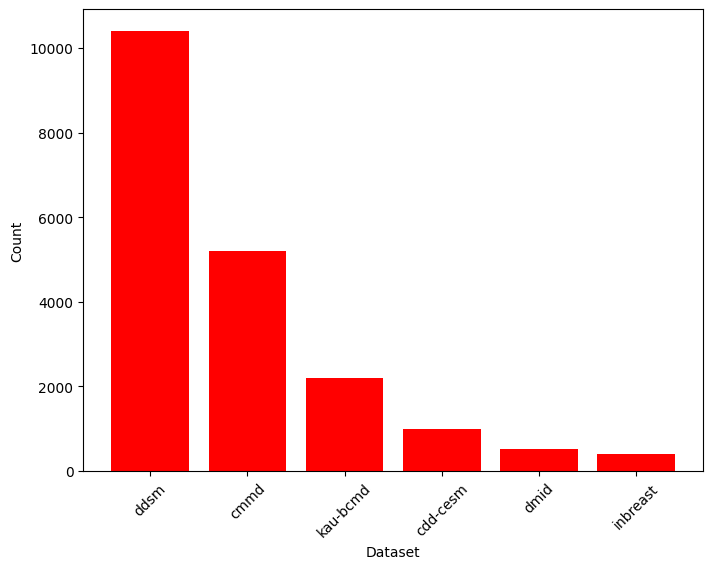

In [13]:
# source_counts = df['source_dataset'].value_counts()
# import matplotlib.pyplot as plt
# import numpy as np
# import os

# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111, projection='3d')
# x_labels = source_counts.index
# xs = np.arange(len(x_labels))
# ys = np.zeros(len(x_labels))
# zs = np.zeros(len(x_labels))
# dx = np.ones(len(x_labels)) * 0.5
# dy = np.ones(len(x_labels)) * 0.5
# dz = source_counts.values

# ax.bar3d(xs, ys, zs, dx, dy, dz, color='skyblue')
# ax.set_xticks(xs)
# ax.set_xticklabels(x_labels, rotation=45)
# ax.set_title("Source Dataset Distribution ")
# plt.savefig(r"D:\\Thesis_folder\\plots_folder\\source_3d_bar.png", bbox_inches='tight')
# plt.show()
source_counts = df['source_dataset'].value_counts()

import matplotlib.pyplot as plt
import numpy as np

x_labels = source_counts.index
xs = np.arange(len(x_labels))
values = source_counts.values

plt.figure(figsize=(8, 6))
plt.bar(xs, values, color='red')

plt.xticks(xs, x_labels, rotation=45)
plt.xlabel("Dataset")
plt.ylabel("Count")

plt.savefig(r"D:\\Thesis_folder\\plots_folder\\source_2d_bar.pdf", bbox_inches='tight')
plt.show()

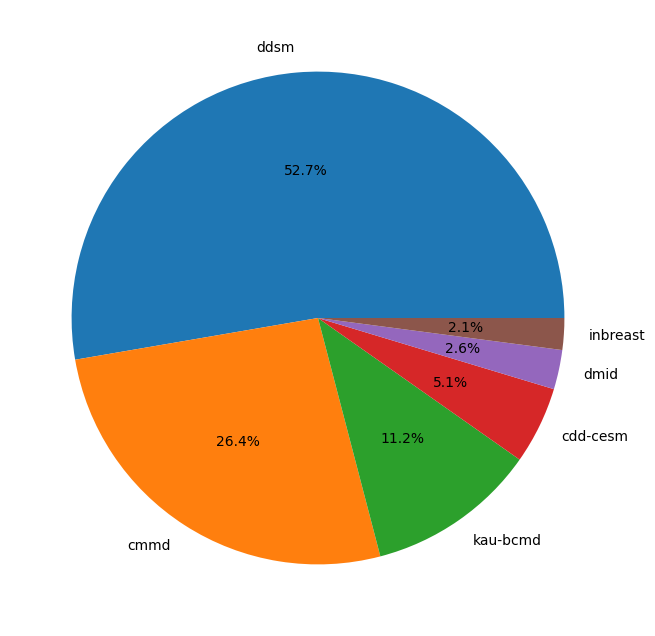

In [14]:
# pie chart (Source destribution)
saved_folder = r"D:\Thesis_folder\plots_folder"
os.makedirs(saved_folder,exist_ok=True)
plt.figure(figsize=(8,8))
source_counts.plot(kind='pie',autopct='%1.1f%%')
# plt.title("Source Dataset Contribution (Pie chart)")
plt.ylabel("")
plt.savefig(r"D:\Thesis_folder\plots_folder\source_dataset_pie_chart.pdf",bbox_inches='tight')
plt.show()


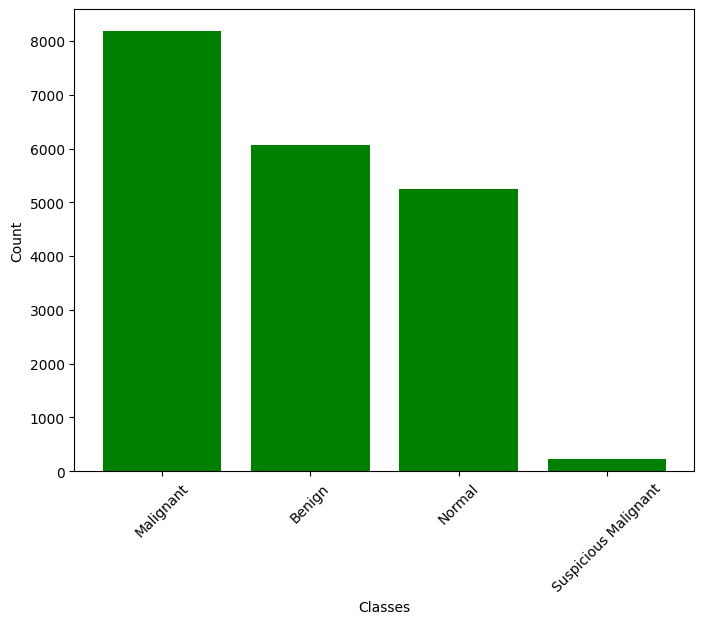

In [15]:
# class_counts = df['classification'].value_counts()
# import matplotlib.pyplot as plt
# import numpy as np
# import os

# fig = plt.figure(figsize=(8, 6))
# ax = fig.add_subplot(111, projection='3d')
# x_labels = class_counts.index
# xs = np.arange(len(x_labels))
# ys = np.zeros(len(x_labels))
# zs = np.zeros(len(x_labels))
# dx = np.ones(len(x_labels)) * 0.5
# dy = np.ones(len(x_labels)) * 0.5
# dz = class_counts.values

# ax.bar3d(xs, ys, zs, dx, dy, dz, color='skyblue')
# ax.set_xticks(xs)
# ax.set_xticklabels(x_labels, rotation=45)
# ax.set_title("Class Distribution")
# plt.savefig(r"D:\\Thesis_folder\\plots_folder\\class_3d_bar.png", bbox_inches='tight')
# plt.show()
class_counts = df['classification'].value_counts()

import matplotlib.pyplot as plt
import numpy as np

x_labels = class_counts.index
x = np.arange(len(x_labels))
y = class_counts.values

plt.figure(figsize=(8, 6))
plt.bar(x, y, color='green')

plt.xticks(x, x_labels, rotation=45)
# plt.title("Class Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")

plt.savefig(r"D:\\Thesis_folder\\plots_folder\\class_2d_bar.pdf", bbox_inches='tight')
plt.show()

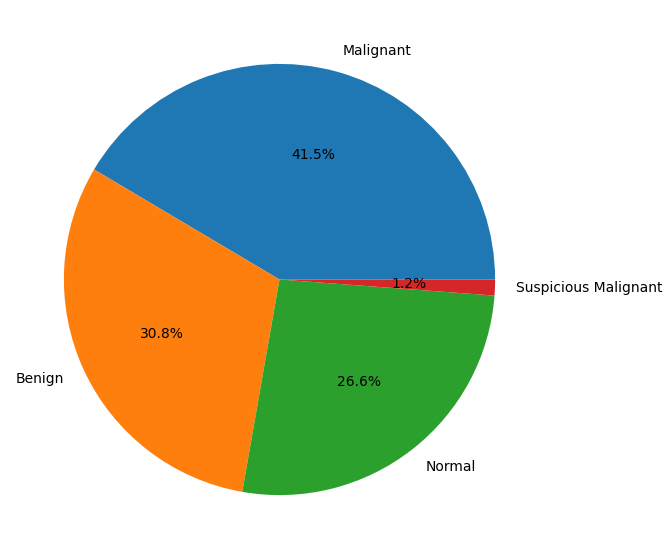

In [16]:
# Class distribution pie chart
os.makedirs(saved_folder,exist_ok=True)
plt.figure(figsize=(7,7))
class_counts.plot(kind='pie',autopct='%1.1f%%')
# plt.title("Class Distribution Ratio (Pie chart)")
plt.ylabel("")
plt.savefig(r"D:\Thesis_folder\plots_folder\Class_distribution_ratio_pie_chart.pdf",bbox_inches='tight')
plt.show()

In [17]:
# Checking Data is balanced or not
print(class_counts)

classification
Malignant               8184
Benign                  6069
Normal                  5243
Suspicious Malignant     235
Name: count, dtype: int64


In [18]:
# imbalance checking
max_class = class_counts.max()
min_class = class_counts.min()
print("Max class size:",max_class)
print("Min class size:",min_class)
ratio = max_class / min_class
if ratio > 1.5:
    print("Dataset is imbalanced")
else:
    print("Dataset is Relatively Balanced")

Max class size: 8184
Min class size: 235
Dataset is imbalanced


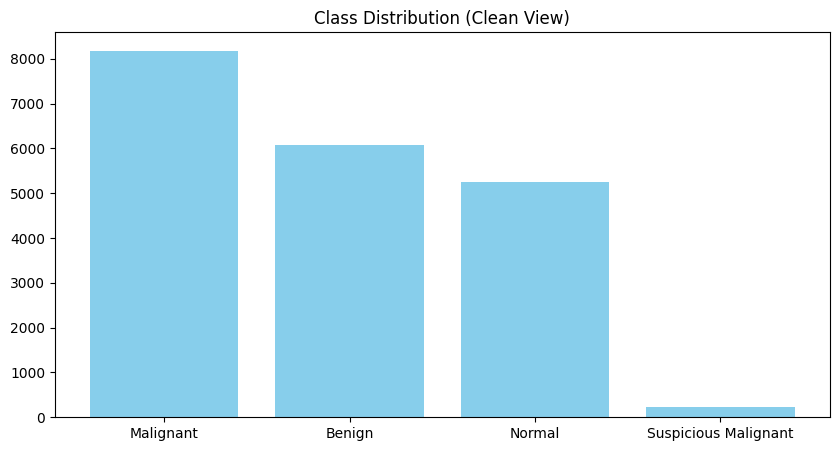

In [19]:
# Advanced visualization
plt.figure(figsize=(10,5))
plt.bar(class_counts.index,class_counts.values,color='skyblue')
plt.title("Class Distribution (Clean View)")
plt.show()

In [20]:
if ratio > 1.5:
    print("""
Conclusion:
The dataset is imbalanced. This may bias the model toward majority classes.
To handle this, techniques such as:
- class weighting
- oversampling (SMOTE)
- data augmentation
can be applied.

However, in medical imaging, imbalance is common and sometimes preserved to reflect real-world distribution.
""")
else:
    print("""
Conclusion:
The dataset is relatively balanced, which is suitable for training deep learning models without major bias concerns.
""")


Conclusion:
The dataset is imbalanced. This may bias the model toward majority classes.
To handle this, techniques such as:
- class weighting
- oversampling (SMOTE)
- data augmentation
can be applied.

However, in medical imaging, imbalance is common and sometimes preserved to reflect real-world distribution.



In [21]:
print(df.columns)

Index(['source_dataset', 'preprocessed_image_path', 'classification',
       'density', 'BIRADS', 'mask_path', 'raw_image_path', 'laterality',
       'view', 'source_subjectID', 'original_source_path', 'subject_age',
       'abnormality', 'molecular_subtype', 'ROI_path', 'x', 'y', 'radius',
       'abnormality id', 'calc type', 'calc distribution', 'subtlety',
       'mass shape', 'mass margins', 'cropped_image_file_new'],
      dtype='object')


In [22]:
# train-test split code
from sklearn.model_selection import train_test_split
# clean columns names
df.columns = df.columns.str.strip()
# print(df.columns)
x = df.drop("classification",axis=1)
# print(x)
y = df['classification']
# print(y)
# most important train test split
x_train,x_test,y_train,y_test = train_test_split(
    x,y,
    test_size=0.2,
    # 80% train,20% test
    random_state=42,
    # keeps class balance
    stratify=y
)

In [23]:
train_counts = y_train.value_counts()
print(train_counts)
print("-"*40)
test_counts = y_test.value_counts()
print(test_counts)

classification
Malignant               6547
Benign                  4855
Normal                  4194
Suspicious Malignant     188
Name: count, dtype: int64
----------------------------------------
classification
Malignant               1637
Benign                  1214
Normal                  1049
Suspicious Malignant      47
Name: count, dtype: int64


In [24]:
# Malignant: 6547 + 1637 = 8184
# Benign: 4855 + 1214 = 6069
# Normal: 4194 + 1049 = 5243
# Suspicious: 188 + 47 = 235

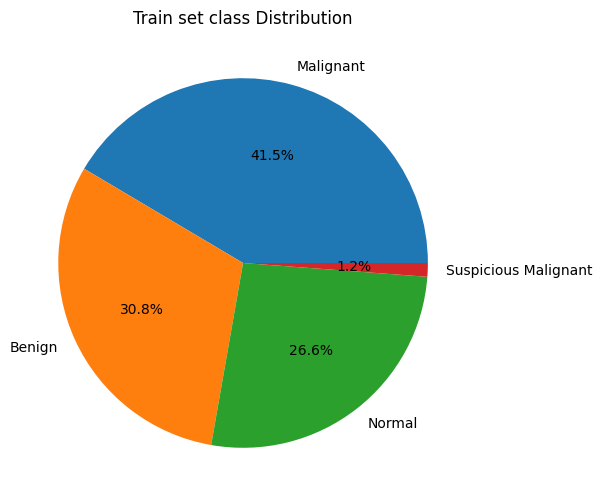

In [25]:
# Pie charts
# Train set class distribution
saved_folder=r"D:\Thesis_folder\plots_folder"
os.makedirs(saved_folder,exist_ok=True)
plt.figure(figsize=(6,6))
train_counts.plot(kind='pie',autopct='%.1f%%')
plt.title("Train set class Distribution")
plt.ylabel("")
plt.savefig(r"D:\Thesis_folder\plots_folder\Train_set_class_distribution_pie_chart.png",bbox_inches='tight')
plt.show()


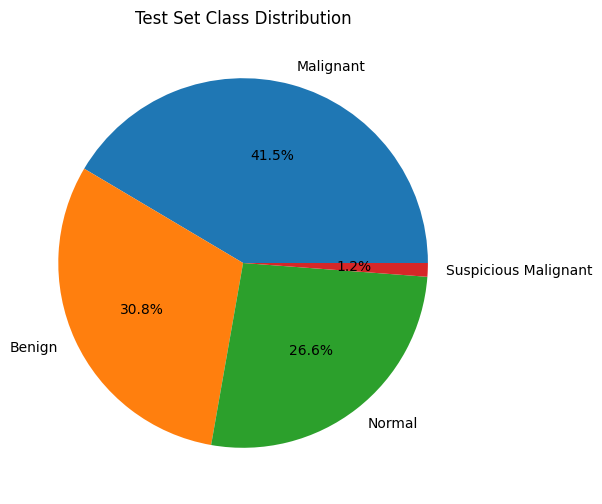

In [26]:
# test set class distribution
plt.figure(figsize=(6,6))
test_counts.plot(kind='pie',autopct='%.1f%%')
plt.title("Test Set Class Distribution")
plt.ylabel("")
plt.show()


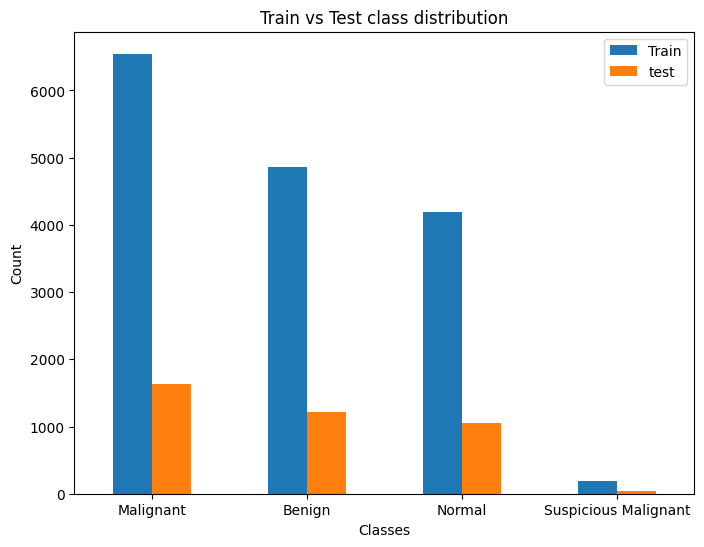

In [27]:
# Bar chart comparison
dist_df = pd.DataFrame({
    "Train":train_counts,
    "test":test_counts}).fillna(0)
dist_df.plot(kind='bar',figsize=(8,6))
plt.title("Train vs Test class distribution")
plt.xlabel("Classes")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.savefig(r"D:\Thesis_folder\plots_folder\train_test_distribution.png")
plt.show()


In [28]:
# import os
# import shutil
# import pandas as pd
# df = pd.read_csv(r"D:\Thesis_folder\mammobench\Mammo_Bench_v2\CSV_Files\mammo-bench.csv")
# output_base_dir = r"D:\Thesis_folder\classification_folders"
# image_base_dir = r"D:\Thesis_folder\mammobench\Mammo_Bench_v2"
# os.makedirs(output_base_dir, exist_ok=True)

# print("Starting organization...")

# for index, row in df.iterrows():

#     # classification folder
#     classification = row['classification'].replace(' ', '_')

#     # raw image path from CSV
#     raw_path = row['raw_image_path']

#     # 🔥 FIX: handle full or relative path
#     if raw_path.startswith("D:") or raw_path.startswith("C:"):
#         full_path = raw_path
#     else:
#         full_path = os.path.join(image_base_dir, raw_path)

#     # destination folder
#     dest_dir = os.path.join(output_base_dir, classification, "raw_images")
#     os.makedirs(dest_dir, exist_ok=True)

#     # copy file
#     if os.path.exists(full_path):
#         shutil.copy(full_path, dest_dir)
#     else:
#         print("Missing:", full_path)

#     # progress
#     if index % 1000 == 0:
#         print(f"Processed {index}/{len(df)}")

# print("DONE ✔ Image organization complete!")

In [29]:
image_to_class = dict(zip(df['raw_image_path'],df['classification']))

In [30]:
def get_classification(image_name):
    for path,cls in image_to_class.items():
        if image_name in path:
            return cls
    return "Image not found"
while True:
    img = input("Enter image name:")
    if img.lower() == "exit":
        print("program stopped")
        break
    result = get_classification(img)
    print("Classification:",result)
    print("-"*40)

Enter image name: exit


program stopped


In [31]:
# ------------------- 2nd Part-----------------------------

In [32]:
# Data Analysis part

In [33]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split
import numpy as np

In [34]:
# Dataset path
dataset_path = r"D:\Thesis_folder\classification_folders"
folder = r"D:\Thesis_folder\classification_folders\Benign\raw_images"
print(os.listdir(folder)[:10])
print("done")

['cdd-cesm_1.jpg', 'cdd-cesm_1000.jpg', 'cdd-cesm_103.jpg', 'cdd-cesm_104.jpg', 'cdd-cesm_105.jpg', 'cdd-cesm_106.jpg', 'cdd-cesm_111.jpg', 'cdd-cesm_112.jpg', 'cdd-cesm_113.jpg', 'cdd-cesm_114.jpg']
done


In [35]:
# class names
classes = [
    "Benign",
    "Malignant",
    "Normal",
    "Suspicious_Malignant"
]


In [36]:
# store image counts
print("started")
class_counts = {}
for class_name in classes:
    # class_folder = os.path.join(dataset_path,class_name)
    class_folder = os.path.join(
        dataset_path,
        class_name,
        "raw_images"
    )
    image_names = [
        img for img in os.listdir(class_folder)
        if img.endswith(('.png', '.jpg', '.jpeg'))
    ]
    class_counts[class_name] = len(image_names)
print("done")

started
done


In [37]:
# print counts
print("Dataset Distribution:\n")
for key,value in class_counts.items():
    print(f"{key}:{value}")

Dataset Distribution:

Benign:6069
Malignant:8184
Normal:5243
Suspicious_Malignant:235


started taking 4 raw images


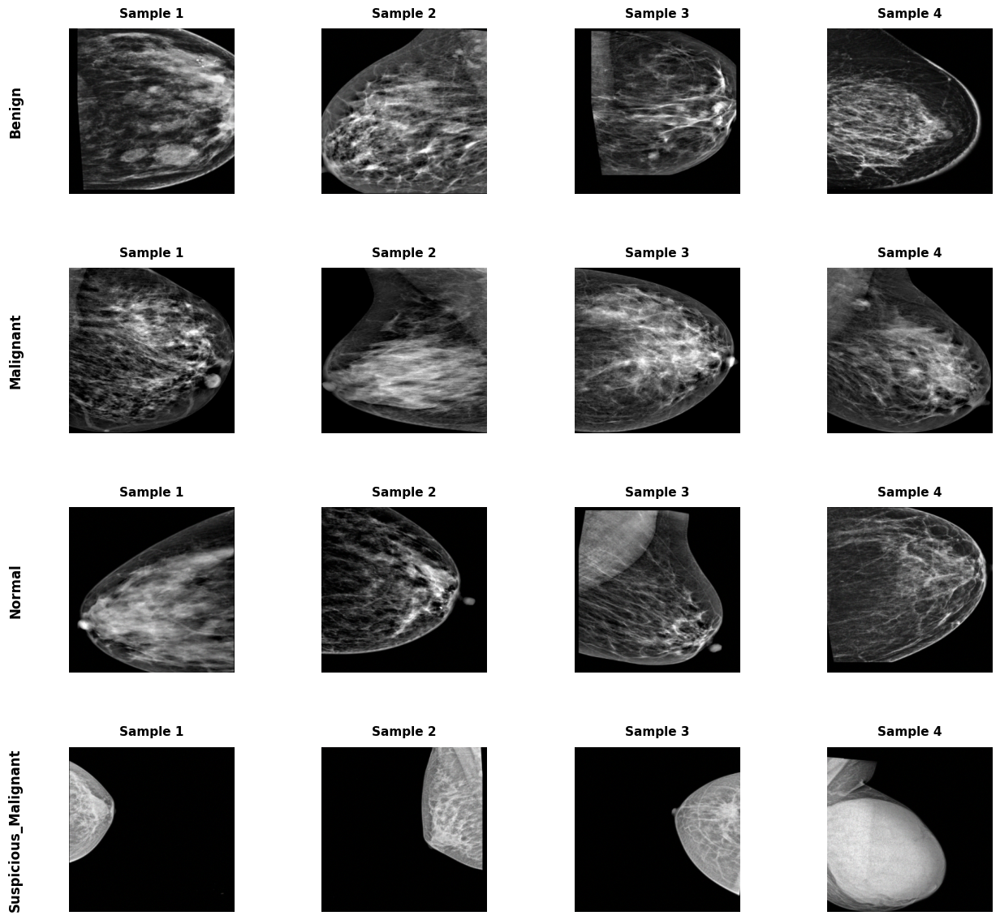

Done


In [38]:
print("started taking 4 raw images")

import os
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

dataset_path = r"D:\Thesis_folder\classification_folders"
classes = os.listdir(dataset_path)

# -------- SETTINGS --------
samples_per_class = 4
image_size = (300, 300)   # all images same size
# --------------------------

rows = len(classes)
cols = samples_per_class

fig, axes = plt.subplots(
    rows,
    cols,
    figsize=(14, rows * 3)
)

# if only one row
if rows == 1:
    axes = [axes]

for row_idx, cls in enumerate(classes):

    class_path = os.path.join(dataset_path, cls)

    # find subfolder (example: raw_images)
    subfolders = os.listdir(class_path)

    selected_images = []

    for sub in subfolders:
        sub_path = os.path.join(class_path, sub)

        if os.path.isdir(sub_path):

            images = [
                f for f in os.listdir(sub_path)
                if f.lower().endswith(('.jpg', '.png', '.jpeg'))
            ]

            selected_images.extend(images)

    # take only first 4 images
    selected_images = selected_images[:samples_per_class]

    for col_idx in range(samples_per_class):

        ax = axes[row_idx][col_idx]

        # if image exists
        if col_idx < len(selected_images):

            img_name = selected_images[col_idx]

            # find actual image path
            img_path = None

            for sub in subfolders:
                sub_path = os.path.join(class_path, sub)

                if os.path.isdir(sub_path):
                    temp_path = os.path.join(sub_path, img_name)

                    if os.path.exists(temp_path):
                        img_path = temp_path
                        break

            # read image
            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            # resize to same size
            img = cv2.resize(img, image_size)

            ax.imshow(img)

            # sample title
            ax.set_title(
                f"Sample {col_idx + 1}",
                fontsize=11,
                fontweight='bold',
                pad=10
            )

        ax.axis("off")

        # write class name on left side of first column
        if col_idx == 0:
            ax.text(
                -0.28,               # left side
                0.5,
                cls,
                transform=ax.transAxes,
                fontsize=12,
                fontweight='bold',
                va='center',
                ha='right',
                rotation=90
            )

# professional spacing
plt.tight_layout()
plt.subplots_adjust(
    left=0.12,
    top=0.92,
    hspace=0.45,
    wspace=0.10
)

plt.savefig(
    r"D:\Thesis_folder\plots_folder\four_images.pdf",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

print("Done")

started taking 4 random images using loop


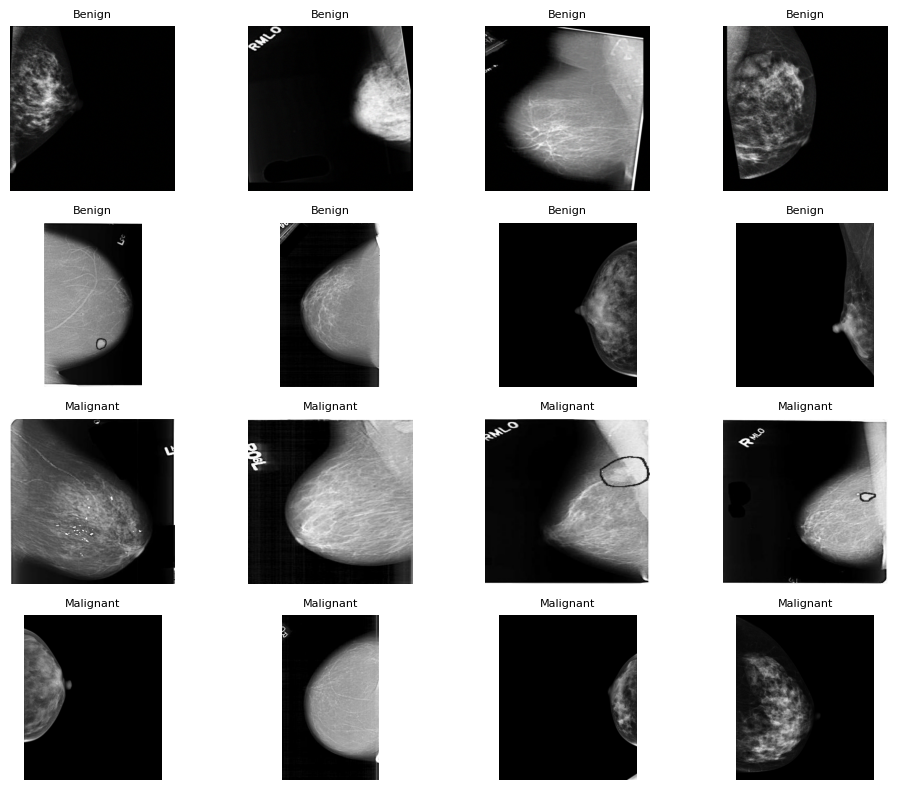

done


In [39]:
print("started taking 4 random images using loop")
import os
import cv2
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
dataset_path2 =  r"D:\Thesis_folder\classification_folders"
classes = os.listdir(dataset_path2)
fig = plt.figure(figsize=(10,8))
img_num = 1
max_slots = len(classes)*4
for cls in classes:
    class_path = os.path.join(dataset_path2,cls)
    # going inside subfolders like raw images
    subfolders = os.listdir(class_path)
    for sub in subfolders:
        sub_path = os.path.join(class_path,sub)
        # only if it is a folder
        if os.path.isdir(sub_path):
            images = [f for f in os.listdir(sub_path) if f.endswith(('.jpg', '.png', '.jpeg'))]
            # random_images = random.sample(images,4)
            if len(images) == 0:
                continue
            random_images = random.sample(images, min(4, len(images)))
            for img_name in random_images:
                if img_num > max_slots:
                    break
                img_path = os.path.join(sub_path,img_name)
                img = mpimg.imread(img_path)
                img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
                ax = fig.add_subplot(len(classes), 4, img_num)
                ax.imshow(img)
                ax.axis("off")
                ax.set_title(cls,fontsize=8)
                img_num += 1
plt.tight_layout()
plt.savefig("dataset_collage.pdf")
plt.show()
print("done")

starting bar chart


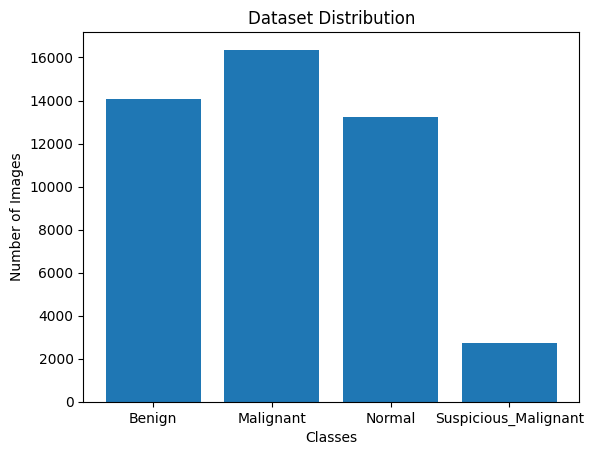

done


In [40]:
# Bar chart
print("starting bar chart")
import os
import matplotlib.pyplot as plt
dataset_path = r"D:\Thesis_folder\classification_folders"
classes = os.listdir(dataset_path)
counts = []
for cls in classes:
    class_path = os.path.join(dataset_path,cls)
    total_images = 0
    for sub in os.listdir(class_path):
        sub_path = os.path.join(class_path,sub)
        if os.path.isdir(sub_path):
            images = [f for f in os.listdir(sub_path)
                      if f.endswith(('.jpg', '.png', '.jpeg'))]
            total_images += len(images)
    counts.append(total_images)
plt.bar(classes,counts)
plt.xlabel("Classes")
plt.ylabel("Number of Images")
plt.title("Dataset Distribution")
plt.savefig("dataset_bar.pdf")
plt.show()
print("done")

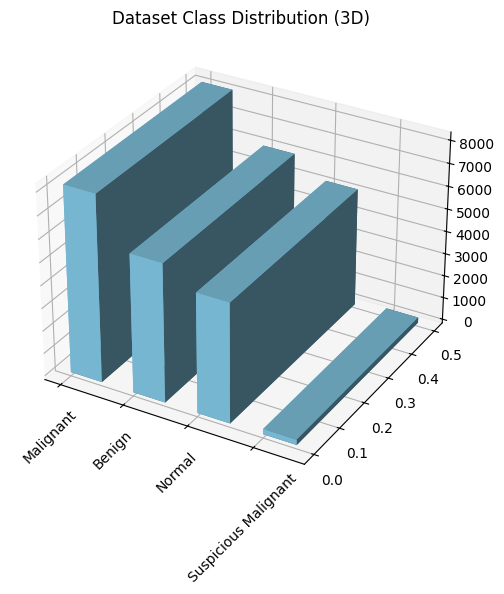

In [41]:
dataset_counts = train_counts + test_counts
import matplotlib.pyplot as plt
import numpy as np
import os

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
x_labels = dataset_counts.index
xs = np.arange(len(x_labels))
ys = np.zeros(len(x_labels))
zs = np.zeros(len(x_labels))
dx = np.ones(len(x_labels)) * 0.5
dy = np.ones(len(x_labels)) * 0.5
dz = dataset_counts.values

ax.bar3d(xs, ys, zs, dx, dy, dz, color='skyblue')
ax.set_xticks(xs)
ax.set_xticklabels(x_labels, rotation=45)
ax.set_title("Dataset Class Distribution (3D)")
plt.savefig(r"D:\\Thesis_folder\\plots_folder\\dataset_counts_3d.png", bbox_inches='tight')
plt.show()


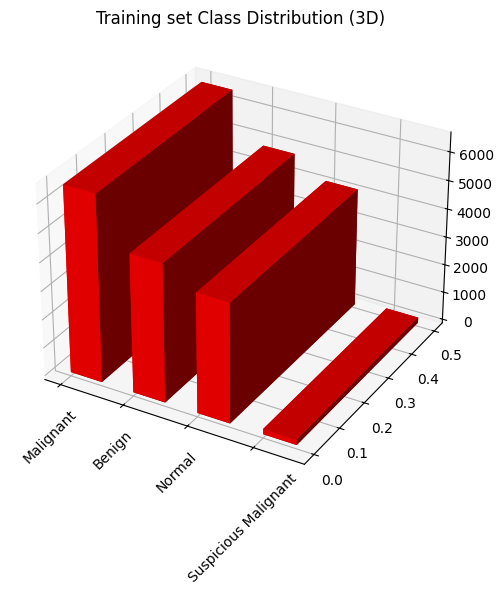

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import os

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
x_labels = train_counts.index
xs = np.arange(len(x_labels))
ys = np.zeros(len(x_labels))
zs = np.zeros(len(x_labels))
dx = np.ones(len(x_labels)) * 0.5
dy = np.ones(len(x_labels)) * 0.5
dz = train_counts.values

ax.bar3d(xs, ys, zs, dx, dy, dz, color='red')
ax.set_xticks(xs)
ax.set_xticklabels(x_labels, rotation=45)
ax.set_title("Training set Class Distribution (3D)")
plt.savefig(r"D:\\Thesis_folder\\plots_folder\\train_counts_3d.png", bbox_inches='tight')
plt.show()


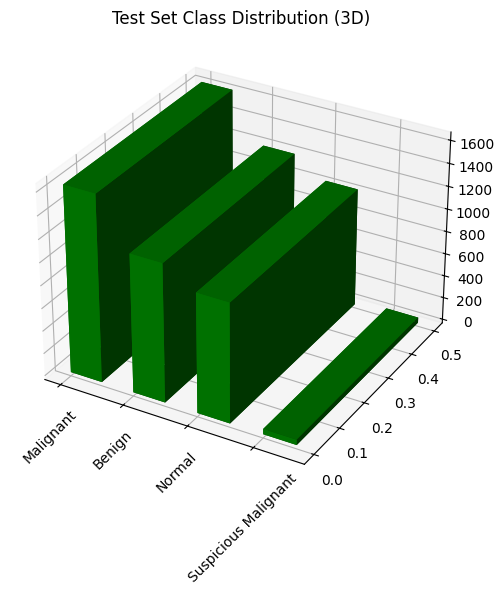

In [43]:
import matplotlib.pyplot as plt
import numpy as np
import os

fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection='3d')
x_labels = test_counts.index
xs = np.arange(len(x_labels))
ys = np.zeros(len(x_labels))
zs = np.zeros(len(x_labels))
dx = np.ones(len(x_labels)) * 0.5
dy = np.ones(len(x_labels)) * 0.5
dz = test_counts.values

ax.bar3d(xs, ys, zs, dx, dy, dz, color='green')
ax.set_xticks(xs)
ax.set_xticklabels(x_labels, rotation=45)
ax.set_title("Test Set Class Distribution (3D)")
plt.savefig(r"D:\\Thesis_folder\\plots_folder\\test_counts_3d.png", bbox_inches='tight')
plt.show()


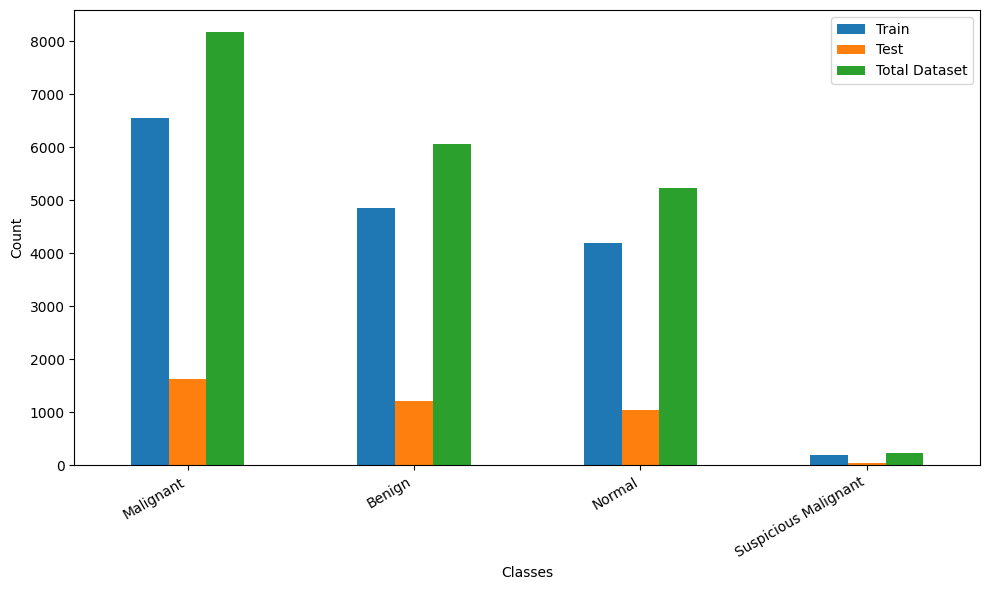

In [44]:
# Train vs Test vs Total (3 columns per class)

total_counts = train_counts + test_counts

dist_df = pd.DataFrame({
    "Train": train_counts,
    "Test": test_counts,
    "Total Dataset": total_counts
}).fillna(0)

ax = dist_df.plot(
    kind='bar',
    figsize=(10, 6)
)

# plt.title("Train vs Test vs Total Dataset Distribution")
plt.xlabel("Classes")
plt.ylabel("Count")

# Rotate class names slightly for readability
plt.xticks(rotation=30, ha='right')

plt.legend()

plt.tight_layout()   # cleaner spacing for report/thesis

plt.savefig(
    r"D:\Thesis_folder\plots_folder\train_test_total_bar_chart.pdf",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

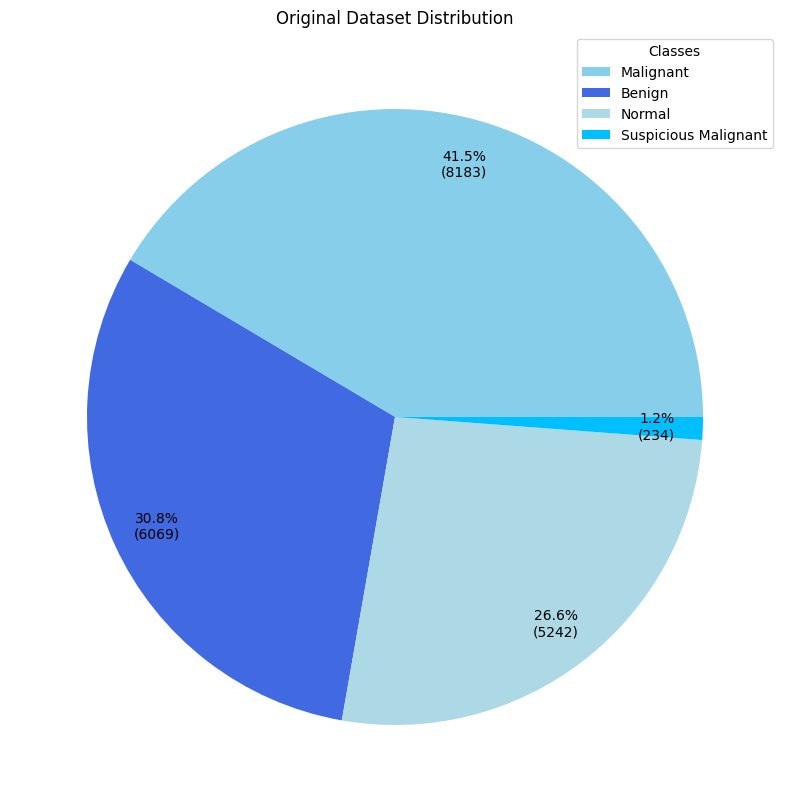

In [45]:
# Original Dataset
plt.figure(figsize=(10,10))

plt.pie(dataset_counts,
        labels=None,
        autopct=lambda p: f'{p:.1f}%\n({int(p*sum(dataset_counts)/100)})',
        colors=['skyblue','royalblue','lightblue','deepskyblue'],
        pctdistance=0.85)

plt.legend(dataset_counts.index,
           title="Classes",
           loc="best")

plt.title("Original Dataset Distribution")

plt.savefig(r"D:\Thesis_folder\plots_folder\dataset_pie.png",
            bbox_inches='tight')

plt.show()


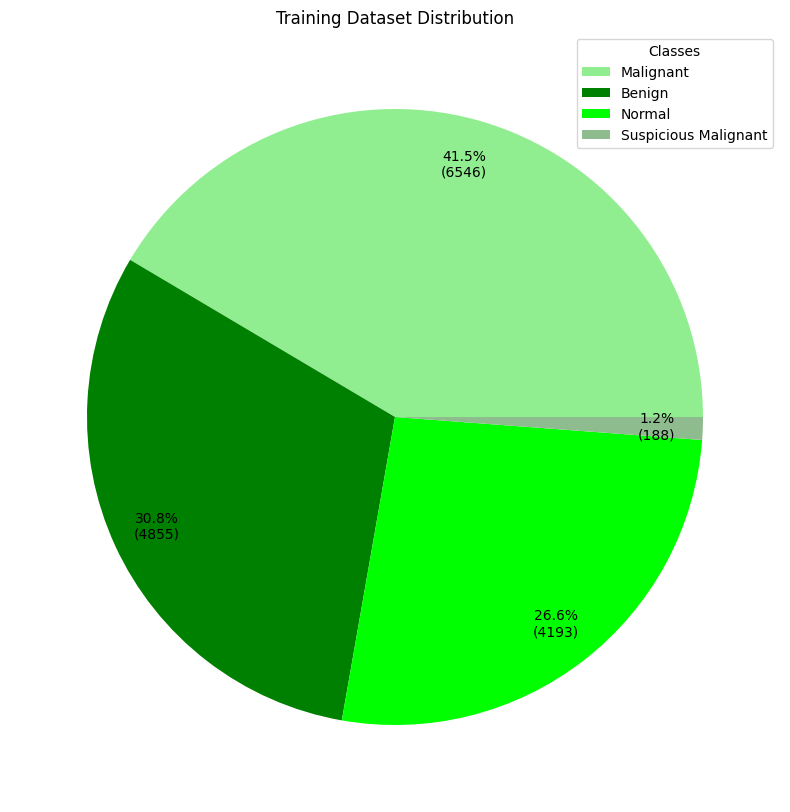

In [46]:
# Train Pie chart
plt.figure(figsize=(10,10))

plt.pie(train_counts,
        labels=None,
        autopct=lambda p: f'{p:.1f}%\n({int(p*sum(train_counts)/100)})',
        colors=['lightgreen','green','lime','darkseagreen'],
        pctdistance=0.85)

plt.legend(train_counts.index,
           title="Classes",
           loc="best")

plt.title("Training Dataset Distribution")

plt.savefig(r"D:\Thesis_folder\plots_folder\train_pie.png",
            bbox_inches='tight')

plt.show()

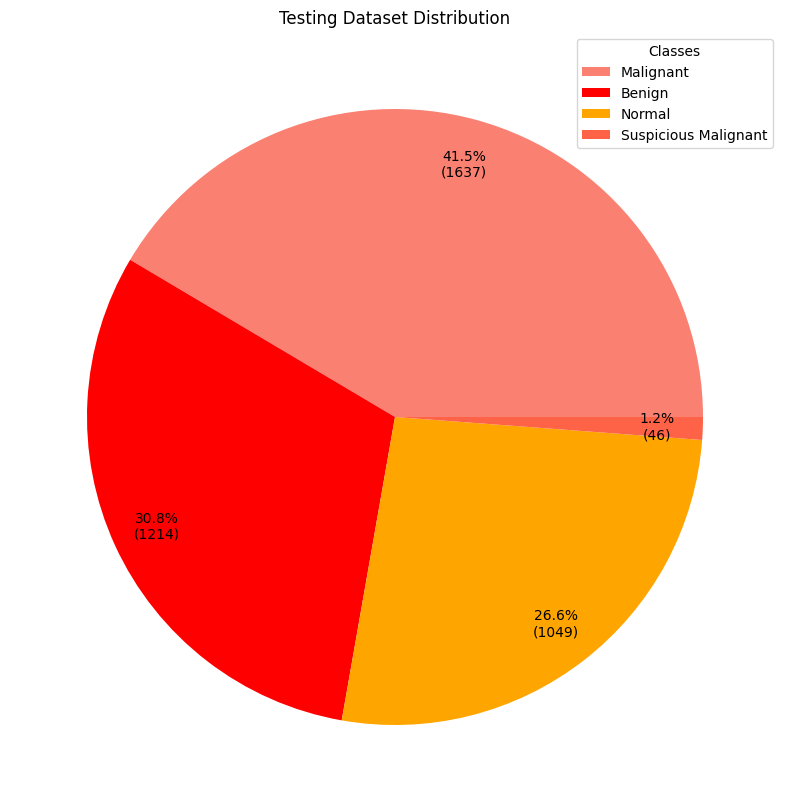

In [47]:
# Test pie chart
plt.figure(figsize=(10,10))

plt.pie(test_counts,
        labels=None,
        autopct=lambda p: f'{p:.1f}%\n({int(p*sum(test_counts)/100)})',
        colors=['salmon','red','orange','tomato'],
        pctdistance=0.85)

plt.legend(test_counts.index,
           title="Classes",
           loc="best")

plt.title("Testing Dataset Distribution")

plt.savefig(r"D:\Thesis_folder\plots_folder\test_pie.png",
            bbox_inches='tight')

plt.show()

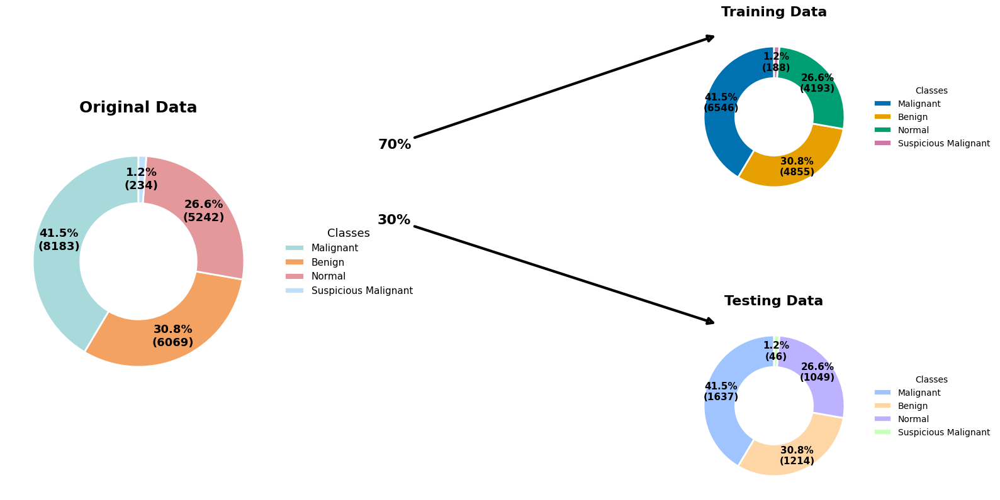

In [48]:
# ==========================================================
# Combined Pie Chart (Original -> Train/Test)
# ==========================================================

import matplotlib.pyplot as plt

# ----------------------------------------------------------
# Figure
# ----------------------------------------------------------
fig = plt.figure(figsize=(20, 10), facecolor='white')

# ----------------------------------------------------------
# Layout (based on your sketch)
# ----------------------------------------------------------
ax_original = fig.add_axes([0.05, 0.28, 0.30, 0.42])
ax_train = fig.add_axes([0.58, 0.58, 0.25, 0.28])
ax_test = fig.add_axes([0.58, 0.12, 0.25, 0.28])

# ----------------------------------------------------------
# Colors
# ----------------------------------------------------------
# Original Dataset (Blue Theme)
original_colors = [
    '#A8DADC',  # light teal
    '#F4A261',  # soft orange
    '#E5989B',  # soft pink
    '#BDE0FE'   # light blue
]

# Training Dataset (Purple Theme)
train_colors = [
    '#0072B2',  # blue
    '#E69F00',  # orange
    '#009E73',  # green
    '#CC79A7'   # purple
]

# Testing Dataset (Orange Theme)
test_colors = [
    '#A0C4FF',  # light blue
    '#FFD6A5',  # peach
    '#BDB2FF',  # light purple
    '#CAFFBF'   # light green
]

# ==========================================================
# ORIGINAL DATASET PIE
# ==========================================================
wedges1, _, _ = ax_original.pie(
    dataset_counts,
    labels=None,
    autopct=lambda p:
        f'{p:.1f}%\n({int(p * sum(dataset_counts) / 100)})',
    colors=original_colors,
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(
        width=0.45,           # donut style
        edgecolor='white',
        linewidth=2
    ),
    textprops=dict(
        fontsize=13,
        fontweight='bold'
    )
)


ax_original.set_title(
    "Original Data",
    fontsize=18,
    fontweight='bold',
    pad=20
)

ax_original.legend(
    wedges1,
    dataset_counts.index,
    title="Classes",
    title_fontsize=13,
    fontsize=11,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# ==========================================================
# TRAIN PIE
# ==========================================================
wedges2, _, _ = ax_train.pie(
    train_counts,
    labels=None,
    autopct=lambda p:
        f'{p:.1f}%\n({int(p * sum(train_counts) / 100)})',
    colors=train_colors,
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(
        width=0.45,
        edgecolor='white',
        linewidth=2
    ),
    textprops=dict(
        fontsize=11,
        fontweight='bold'
    )
)

ax_train.set_title(
    "Training Data",
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax_train.legend(
    wedges2,
    train_counts.index,
    title="Classes",
    fontsize=10,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# ==========================================================
# TEST PIE
# ==========================================================
wedges3, _, _ = ax_test.pie(
    test_counts,
    labels=None,
    autopct=lambda p:
        f'{p:.1f}%\n({int(p * sum(test_counts) / 100)})',
    colors=test_colors,
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(
        width=0.45,
        edgecolor='white',
        linewidth=2
    ),
    textprops=dict(
        fontsize=11,
        fontweight='bold'
    )
)

ax_test.set_title(
    "Testing Data",
    fontsize=16,
    fontweight='bold',
    pad=15
)

ax_test.legend(
    wedges3,
    test_counts.index,
    title="Classes",
    fontsize=10,
    loc='center left',
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

# ==========================================================
# ARROWS (matches sketch)
# ==========================================================

# Original --> Train
plt.annotate(
    "70%",
    xy=(0.57, 0.74),
    xytext=(0.30, 0.56),
    xycoords='figure fraction',
    textcoords='figure fraction',
    fontsize=16,
    fontweight='bold',
    arrowprops=dict(
        arrowstyle='-|>',
        lw=3
    )
)

# Original --> Test
plt.annotate(
    "30%",
    xy=(0.57, 0.28),
    xytext=(0.30, 0.44),
    xycoords='figure fraction',
    textcoords='figure fraction',
    fontsize=16,
    fontweight='bold',
    arrowprops=dict(
        arrowstyle='-|>',
        lw=3
    )
)

# ==========================================================
# SAVE
# ==========================================================
plt.savefig(
    r"D:\Thesis_folder\plots_folder\combined_piedata_chart.pdf",
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [49]:
print("Mammography Augmentation Pipeline Starting...")
print("For Suspicious Malignant")
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array, save_img
# from matplotlib.backends.backend_pdf import PdfPages

# -----------------------------
# Paths
# -----------------------------
input_dir = r"D:\Thesis_folder\classification_folders\Suspicious_Malignant\raw_images"
output_dir = r"D:\Thesis_folder\classification_folders\Suspicious_Malignant\preprocessed_images"
vis_img_path = r"D:\Thesis_folder\plots_folder\suspicious_malignant_1.png"

os.makedirs(output_dir, exist_ok=True)

IMG_SIZE = (512, 512)

# -----------------------------
# 1. Horizontal Flip (50% chance)
# -----------------------------
def horizontal_flip(img):
    if np.random.rand() < 0.5:
        return cv2.flip(img, 1)
    return img

# -----------------------------
# 2. Small Rotation (±5°)
# -----------------------------
def rotate(img):
    # angle = np.random.uniform(-5, 5)
    angle = np.random.uniform(-10,10)

    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)

    return cv2.warpAffine(img, M, (w, h))

# -----------------------------
# 3. Translation (Shift ±5%)
# -----------------------------
def translate(img):
    h, w = img.shape[:2]

    # tx = int(np.random.uniform(-0.05, 0.05) * w)
    # ty = int(np.random.uniform(-0.05, 0.05) * h)
    tx = int(np.random.uniform(-0.10, 0.10) * w)
    ty = int(np.random.uniform(-0.10, 0.10) * h)

    M = np.float32([[1, 0, tx],
                    [0, 1, ty]])

    return cv2.warpAffine(img, M, (w, h))

# -----------------------------
# 4. Zoom (±5%)
# -----------------------------
def zoom(img):
    # zoom_factor = np.random.uniform(0.95, 1.05)
    zoom_factor = np.random.uniform(0.90, 1.10)

    h, w = img.shape[:2]
    new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)

    resized = cv2.resize(img, (new_w, new_h))

    if zoom_factor < 1.0:
        pad_h = (h - new_h) // 2
        pad_w = (w - new_w) // 2
        padded = cv2.copyMakeBorder(resized, pad_h, h-new_h-pad_h,
                                     pad_w, w-new_w-pad_w,
                                     cv2.BORDER_CONSTANT, value=0)
        return padded

    start_h = (new_h - h) // 2
    start_w = (new_w - w) // 2
    return resized[start_h:start_h+h, start_w:start_w+w]

# -----------------------------
# 5. Contrast Adjustment (low range)
# -----------------------------
def contrast(img):
    # alpha = np.random.uniform(0.95, 1.05)  # very mild
    alpha = np.random.uniform(0.90, 1.10)
    return np.clip(alpha * img, 0, 255)

# -----------------------------
# 6. Random Crop (very mild)
# -----------------------------
def random_crop(img, crop_size=(500, 500)):
    h, w = img.shape[:2]
    ch, cw = crop_size

    x = np.random.randint(0, w - cw + 1)
    y = np.random.randint(0, h - ch + 1)

    cropped = img[y:y+ch, x:x+cw]
    return cv2.resize(cropped, (w, h))

# -----------------------------
# 7. Elastic Deformation (very slight)
# -----------------------------
def elastic_shift(img):
    h, w = img.shape[:2]

    dx = np.random.randint(-2, 3)
    dy = np.random.randint(-2, 3)

    M = np.float32([[1, 0, dx],
                    [0, 1, dy]])

    return cv2.warpAffine(img, M, (w, h))

# -----------------------------
# 8. Gaussian Noise (very low)
# -----------------------------
def gaussian_noise(img):
    noise = np.random.normal(0, 3, img.shape)  # very low noise
    return img + noise

# -----------------------------
# Full Augmentation Pipeline
# -----------------------------
def augment(img):

    img = horizontal_flip(img)
    img = rotate(img)
    img = translate(img)
    img = zoom(img)
    img = contrast(img)
    img = random_crop(img)
    img = elastic_shift(img)
    img = gaussian_noise(img)

    return img

# -----------------------------
# Load images
# -----------------------------
image_files = [
    f for f in os.listdir(input_dir)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
]

print("Total images:", len(image_files))

# -----------------------------
# Save Augmented Dataset
# -----------------------------
target_images = 2500
count = 0

while count < target_images:

    for img_name in image_files:

        if count >= target_images:
            break

        img_path = os.path.join(input_dir, img_name)

        img = load_img(img_path, target_size=IMG_SIZE)
        img = img_to_array(img)

        original = img.copy()

        augmented = augment(img)

        augmented = np.clip(augmented, 0, 255).astype(np.uint8)

        save_path = os.path.join(output_dir, f"sus_malig_aug_{count}.png")
        save_img(save_path, augmented)

        count += 1

        if count % 100 == 0:
            print(f"{count} images generated")

print("Dataset augmentation completed!")


Mammography Augmentation Pipeline Starting...
For Suspicious Malignant
Total images: 235
100 images generated
200 images generated
300 images generated
400 images generated
500 images generated
600 images generated
700 images generated
800 images generated
900 images generated
1000 images generated
1100 images generated
1200 images generated
1300 images generated
1400 images generated
1500 images generated
1600 images generated
1700 images generated
1800 images generated
1900 images generated
2000 images generated
2100 images generated
2200 images generated
2300 images generated
2400 images generated
2500 images generated
Dataset augmentation completed!


Generating visualization PNG...


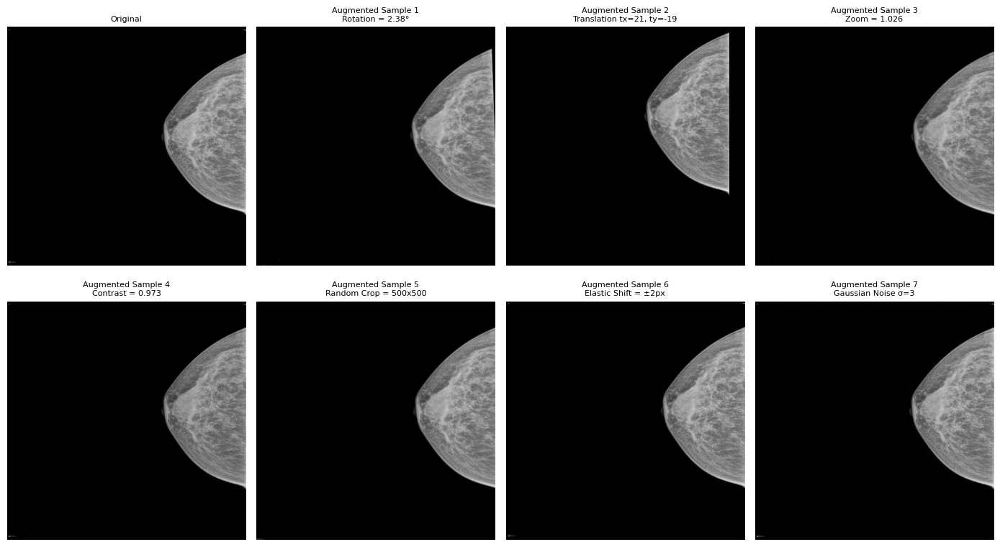

5% visualization saved!


In [50]:
# -----------------------------
# VISUALIZATION WITH ACTUAL VALUES
# -----------------------------
print("Generating visualization PNG...")

sample_img_path = os.path.join(input_dir, image_files[0])

img = load_img(sample_img_path, target_size=IMG_SIZE)
img = img_to_array(img)

# -----------------------------
# Generate ACTUAL values
# -----------------------------
rotation_value = np.random.uniform(-5, 5)

tx_value = int(np.random.uniform(-0.05, 0.05) * 512)
ty_value = int(np.random.uniform(-0.05, 0.05) * 512)

zoom_value = np.random.uniform(0.95, 1.05)

contrast_value = np.random.uniform(0.95, 1.05)

# -----------------------------
# Apply augmentations
# -----------------------------

rot_img = rotate(img.copy())
trans_img = translate(img.copy())
zoom_img = zoom(img.copy())
contrast_img = contrast(img.copy())

imgs = [

    ("Original", img),

    (f"Augmented Sample 1\nRotation = {rotation_value:.2f}°",
     rot_img),

    (f"Augmented Sample 2\nTranslation tx={tx_value}, ty={ty_value}",
     trans_img),

    (f"Augmented Sample 3\nZoom = {zoom_value:.3f}",
     zoom_img),

    (f"Augmented Sample 4\nContrast = {contrast_value:.3f}",
     contrast_img),

    ("Augmented Sample 5\nRandom Crop = 500x500",
     random_crop(img.copy())),

    ("Augmented Sample 6\nElastic Shift = ±2px",
     elastic_shift(img.copy())),

    ("Augmented Sample 7\nGaussian Noise σ=3",
     gaussian_noise(img.copy()))
]

fig, axes = plt.subplots(2, 4, figsize=(14, 8))

axes = axes.flatten()

for i, (title, im) in enumerate(imgs):

    axes[i].imshow(np.clip(im, 0, 255).astype(np.uint8),
                   cmap='gray')

    axes[i].set_title(title, fontsize=8)

    axes[i].axis('off')

plt.tight_layout()

plt.savefig(
    r"D:\Thesis_folder\plots_folder\augmentation_visualization_5percent.pdf",
    dpi=300,
    bbox_inches='tight'
)
plt.show()
plt.close()

print("5% visualization saved!")

Generating 7–10% visualization PNG...


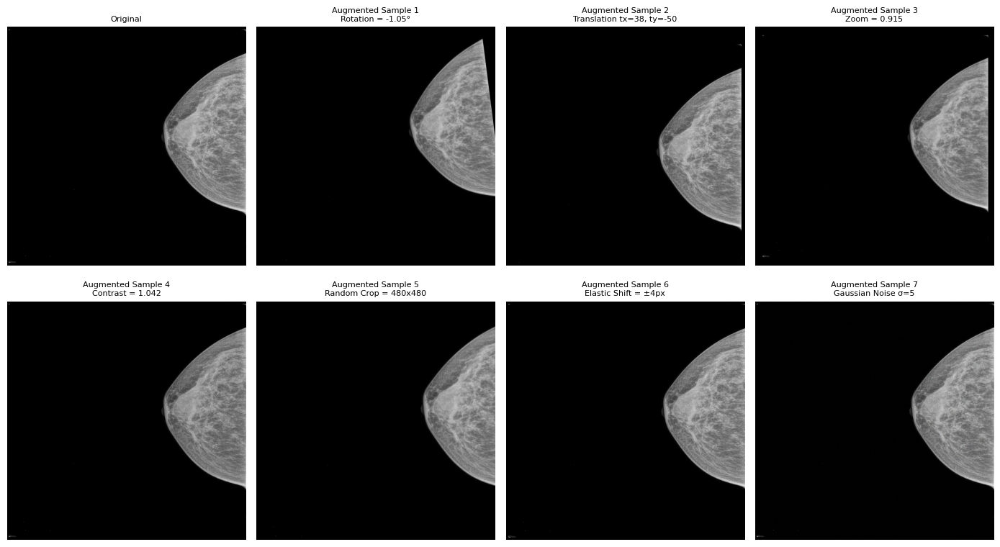

7–10% visualization saved!


In [51]:
print("Generating 7–10% visualization PNG...")

rotation_value = np.random.uniform(-10, 10)

tx_value = int(np.random.uniform(-0.10, 0.10) * 512)
ty_value = int(np.random.uniform(-0.10, 0.10) * 512)

zoom_value = np.random.uniform(0.90, 1.10)

contrast_value = np.random.uniform(0.90, 1.10)

imgs = [

    ("Original", img),

    (f"Augmented Sample 1\nRotation = {rotation_value:.2f}°",
     rotate(img.copy())),

    (f"Augmented Sample 2\nTranslation tx={tx_value}, ty={ty_value}",
     translate(img.copy())),

    (f"Augmented Sample 3\nZoom = {zoom_value:.3f}",
     zoom(img.copy())),

    (f"Augmented Sample 4\nContrast = {contrast_value:.3f}",
     contrast(img.copy())),

    ("Augmented Sample 5\nRandom Crop = 480x480",
     random_crop(img.copy(), crop_size=(480, 480))),

    ("Augmented Sample 6\nElastic Shift = ±4px",
     elastic_shift(img.copy())),

    ("Augmented Sample 7\nGaussian Noise σ=5",
     gaussian_noise(img.copy()))
]

fig, axes = plt.subplots(2, 4, figsize=(14, 8))

axes = axes.flatten()

for i, (title, im) in enumerate(imgs):

    axes[i].imshow(np.clip(im, 0, 255).astype(np.uint8),
                   cmap='gray')

    axes[i].set_title(title, fontsize=8)

    axes[i].axis('off')

plt.tight_layout()

plt.savefig(
    r"D:\Thesis_folder\plots_folder\augmentation_visualization_10percent.pdf",
    dpi=300,
    bbox_inches='tight'
)
plt.show()
plt.close()

print("7–10% visualization saved!")

In [52]:
print("Malignant Image Resizing Starting...")

import os
from tensorflow.keras.preprocessing.image import load_img, img_to_array, save_img

# -----------------------------
# Paths (Malignant)
# -----------------------------
input_dir = r"D:\Thesis_folder\classification_folders\Malignant\raw_images"
output_dir = r"D:\Thesis_folder\classification_folders\Malignant\preprocessed_images"

os.makedirs(output_dir, exist_ok=True)

# -----------------------------
# Resize Dimension
# -----------------------------
IMG_SIZE = (512, 512)

# -----------------------------
# Load Images
# -----------------------------
image_files = [
    f for f in os.listdir(input_dir)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
]

print("Total images:", len(image_files))

# -----------------------------
# Resize and Save Images
# -----------------------------
count = 0

for img_name in image_files:

    img_path = os.path.join(input_dir, img_name)

    # Load and resize image
    img = load_img(img_path, target_size=IMG_SIZE)
    img = img_to_array(img)

    # Save resized image
    save_path = os.path.join(output_dir, img_name)
    save_img(save_path, img)

    count += 1

    if count % 100 == 0:
        print(f"{count} images resized")

print("Malignant image resizing completed!")

Malignant Image Resizing Starting...
Total images: 8184
100 images resized
200 images resized
300 images resized
400 images resized
500 images resized
600 images resized
700 images resized
800 images resized
900 images resized
1000 images resized
1100 images resized
1200 images resized
1300 images resized
1400 images resized
1500 images resized
1600 images resized
1700 images resized
1800 images resized
1900 images resized
2000 images resized
2100 images resized
2200 images resized
2300 images resized
2400 images resized
2500 images resized
2600 images resized
2700 images resized
2800 images resized
2900 images resized
3000 images resized
3100 images resized
3200 images resized
3300 images resized
3400 images resized
3500 images resized
3600 images resized
3700 images resized
3800 images resized
3900 images resized
4000 images resized
4100 images resized
4200 images resized
4300 images resized
4400 images resized
4500 images resized
4600 images resized
4700 images resized
4800 images r

Generating Malignant 5% visualization PNG...


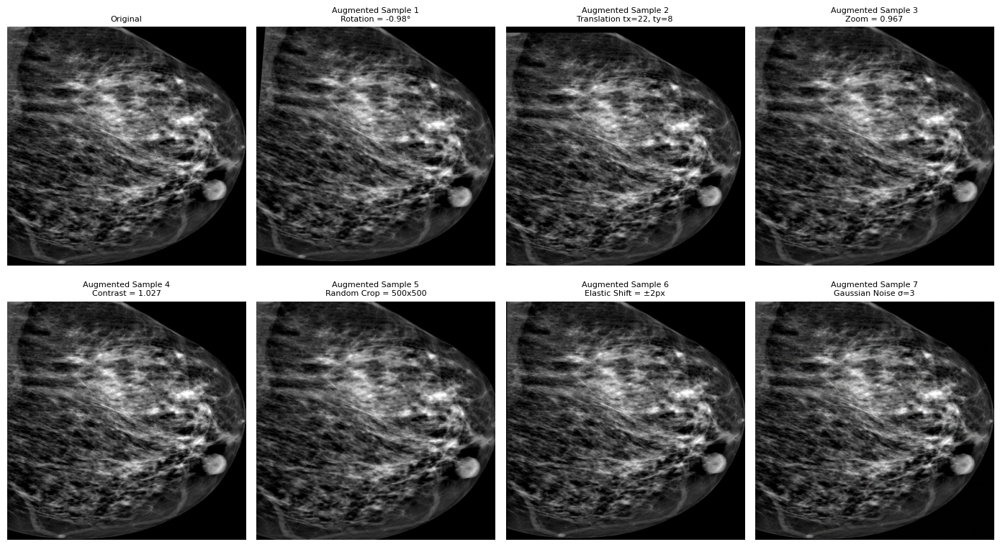

Malignant 5% visualization saved!


In [53]:
# -----------------------------
# VISUALIZATION WITH ACTUAL VALUES (5%)
# FOR MALIGNANT
# -----------------------------
print("Generating Malignant 5% visualization PNG...")

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array

# -----------------------------
# Paths
# -----------------------------
input_dir = r"D:\Thesis_folder\classification_folders\Malignant\raw_images"

IMG_SIZE = (512, 512)

# -----------------------------
# Load images
# -----------------------------
image_files = [
    f for f in os.listdir(input_dir)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
]

sample_img_path = os.path.join(input_dir, image_files[0])

img = load_img(sample_img_path, target_size=IMG_SIZE)
img = img_to_array(img)

# -----------------------------
# 1. Horizontal Flip (50% chance)
# -----------------------------
def horizontal_flip(img):
    if np.random.rand() < 0.5:
        return cv2.flip(img, 1)
    return img

# -----------------------------
# 2. Rotation (±5°)
# -----------------------------
def rotate(img):

    angle = np.random.uniform(-5, 5)

    h, w = img.shape[:2]

    M = cv2.getRotationMatrix2D(
        (w // 2, h // 2),
        angle,
        1.0
    )

    return cv2.warpAffine(img, M, (w, h))

# -----------------------------
# 3. Translation (±5%)
# -----------------------------
def translate(img):

    h, w = img.shape[:2]

    tx = int(np.random.uniform(-0.05, 0.05) * w)
    ty = int(np.random.uniform(-0.05, 0.05) * h)

    M = np.float32([
        [1, 0, tx],
        [0, 1, ty]
    ])

    return cv2.warpAffine(img, M, (w, h))

# -----------------------------
# 4. Zoom (±5%)
# -----------------------------
def zoom(img):

    zoom_factor = np.random.uniform(0.95, 1.05)

    h, w = img.shape[:2]

    new_h = int(h * zoom_factor)
    new_w = int(w * zoom_factor)

    resized = cv2.resize(img, (new_w, new_h))

    if zoom_factor < 1.0:

        pad_h = (h - new_h) // 2
        pad_w = (w - new_w) // 2

        padded = cv2.copyMakeBorder(
            resized,
            pad_h,
            h - new_h - pad_h,
            pad_w,
            w - new_w - pad_w,
            cv2.BORDER_CONSTANT,
            value=0
        )

        return padded

    start_h = (new_h - h) // 2
    start_w = (new_w - w) // 2

    return resized[
        start_h:start_h + h,
        start_w:start_w + w
    ]

# -----------------------------
# 5. Contrast Adjustment (5%)
# -----------------------------
def contrast(img):

    alpha = np.random.uniform(0.95, 1.05)

    return np.clip(alpha * img, 0, 255)

# -----------------------------
# 6. Random Crop
# -----------------------------
def random_crop(img, crop_size=(500, 500)):

    h, w = img.shape[:2]

    ch, cw = crop_size

    x = np.random.randint(0, w - cw + 1)
    y = np.random.randint(0, h - ch + 1)

    cropped = img[y:y + ch, x:x + cw]

    return cv2.resize(cropped, (w, h))

# -----------------------------
# 7. Elastic Shift (±2 px)
# -----------------------------
def elastic_shift(img):

    h, w = img.shape[:2]

    dx = np.random.randint(-2, 3)
    dy = np.random.randint(-2, 3)

    M = np.float32([
        [1, 0, dx],
        [0, 1, dy]
    ])

    return cv2.warpAffine(img, M, (w, h))

# -----------------------------
# 8. Gaussian Noise
# -----------------------------
def gaussian_noise(img):

    noise = np.random.normal(0, 3, img.shape)

    return img + noise

# -----------------------------
# Generate ACTUAL values
# -----------------------------
rotation_value = np.random.uniform(-5, 5)

tx_value = int(np.random.uniform(-0.05, 0.05) * 512)
ty_value = int(np.random.uniform(-0.05, 0.05) * 512)

zoom_value = np.random.uniform(0.95, 1.05)

contrast_value = np.random.uniform(0.95, 1.05)

# -----------------------------
# Apply augmentations
# -----------------------------
rot_img = rotate(img.copy())

trans_img = translate(img.copy())

zoom_img = zoom(img.copy())

contrast_img = contrast(img.copy())

imgs = [

    ("Original", img),

    (
        f"Augmented Sample 1\nRotation = {rotation_value:.2f}°",
        rot_img
    ),

    (
        f"Augmented Sample 2\nTranslation tx={tx_value}, ty={ty_value}",
        trans_img
    ),

    (
        f"Augmented Sample 3\nZoom = {zoom_value:.3f}",
        zoom_img
    ),

    (
        f"Augmented Sample 4\nContrast = {contrast_value:.3f}",
        contrast_img
    ),

    (
        "Augmented Sample 5\nRandom Crop = 500x500",
        random_crop(img.copy())
    ),

    (
        "Augmented Sample 6\nElastic Shift = ±2px",
        elastic_shift(img.copy())
    ),

    (
        "Augmented Sample 7\nGaussian Noise σ=3",
        gaussian_noise(img.copy())
    )
]

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(2, 4, figsize=(14, 8))

axes = axes.flatten()

for i, (title, im) in enumerate(imgs):

    axes[i].imshow(
        np.clip(im, 0, 255).astype(np.uint8),
        cmap='gray'
    )

    axes[i].set_title(
        title,
        fontsize=8
    )

    axes[i].axis('off')

plt.tight_layout()

# -----------------------------
# Save
# -----------------------------
plt.savefig(
    r"D:\Thesis_folder\plots_folder\malignant_augmentation_visualization_5percent.pdf",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print("Malignant 5% visualization saved!")

Generating Malignant 7–10% visualization PNG...


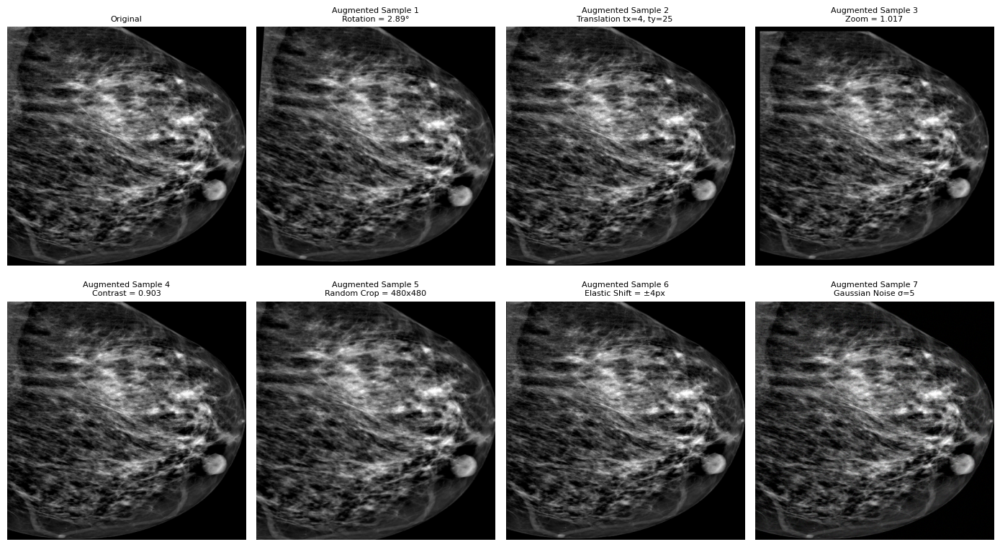

Malignant 7–10% visualization saved!


In [54]:
# -----------------------------
# 7–10% VISUALIZATION
# FOR MALIGNANT IMAGES
# -----------------------------
print("Generating Malignant 7–10% visualization PNG...")

rotation_value = np.random.uniform(-10, 10)

tx_value = int(np.random.uniform(-0.10, 0.10) * 512)
ty_value = int(np.random.uniform(-0.10, 0.10) * 512)

zoom_value = np.random.uniform(0.90, 1.10)

contrast_value = np.random.uniform(0.90, 1.10)

imgs = [

    ("Original", img),

    (
        f"Augmented Sample 1\nRotation = {rotation_value:.2f}°",
        rotate(img.copy())
    ),

    (
        f"Augmented Sample 2\nTranslation tx={tx_value}, ty={ty_value}",
        translate(img.copy())
    ),

    (
        f"Augmented Sample 3\nZoom = {zoom_value:.3f}",
        zoom(img.copy())
    ),

    (
        f"Augmented Sample 4\nContrast = {contrast_value:.3f}",
        contrast(img.copy())
    ),

    (
        "Augmented Sample 5\nRandom Crop = 480x480",
        random_crop(
            img.copy(),
            crop_size=(480, 480)
        )
    ),

    (
        "Augmented Sample 6\nElastic Shift = ±4px",
        elastic_shift(img.copy())
    ),

    (
        "Augmented Sample 7\nGaussian Noise σ=5",
        gaussian_noise(img.copy())
    )
]

# -----------------------------
# Plot
# -----------------------------
fig, axes = plt.subplots(
    2,
    4,
    figsize=(14, 8)
)

axes = axes.flatten()

for i, (title, im) in enumerate(imgs):

    axes[i].imshow(
        np.clip(im, 0, 255).astype(np.uint8),
        cmap='gray'
    )

    axes[i].set_title(
        title,
        fontsize=8
    )

    axes[i].axis('off')

plt.tight_layout()

# -----------------------------
# Save visualization
# -----------------------------
plt.savefig(
    r"D:\Thesis_folder\plots_folder\malignant_augmentation_visualization_10percent.pdf",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print("Malignant 7–10% visualization saved!")

In [55]:
print("Mammography Augmentation Pipeline Starting...")
print("For Benign")

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array, save_img
# from matplotlib.backends.backend_pdf import PdfPages

# -----------------------------
# Paths (ONLY CHANGE HERE)
# -----------------------------
input_dir = r"D:\Thesis_folder\classification_folders\Benign\raw_images"
output_dir = r"D:\Thesis_folder\classification_folders\Benign\preprocessed_images"
vis_img_path = r"D:\Thesis_folder\plots_folder\benign_1.png"

os.makedirs(output_dir, exist_ok=True)

IMG_SIZE = (512, 512)

# -----------------------------
# SAME AUGMENTATION FUNCTIONS
# -----------------------------

def horizontal_flip(img):
    if np.random.rand() < 0.5:
        return cv2.flip(img, 1)
    return img


def rotate(img):
    # angle = np.random.uniform(-5, 5)
    angle = np.random.uniform(-10, 10)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h))


def translate(img):
    h, w = img.shape[:2]
    # tx = int(np.random.uniform(-0.05, 0.05) * w)
    # ty = int(np.random.uniform(-0.05, 0.05) * h)
    tx = int(np.random.uniform(-0.10, 0.10) * w)
    ty = int(np.random.uniform(-0.10, 0.10) * h)
    M = np.float32([[1, 0, tx],
                    [0, 1, ty]])
    return cv2.warpAffine(img, M, (w, h))


def zoom(img):
    # zoom_factor = np.random.uniform(0.95, 1.05)
    zoom_factor = np.random.uniform(0.90, 1.10)
    h, w = img.shape[:2]

    new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)
    resized = cv2.resize(img, (new_w, new_h))

    if zoom_factor < 1.0:
        pad_h = (h - new_h) // 2
        pad_w = (w - new_w) // 2
        return cv2.copyMakeBorder(
            resized,
            pad_h, h-new_h-pad_h,
            pad_w, w-new_w-pad_w,
            cv2.BORDER_CONSTANT, value=0
        )

    start_h = (new_h - h) // 2
    start_w = (new_w - w) // 2
    return resized[start_h:start_h+h, start_w:start_w+w]


def contrast(img):
    # alpha = np.random.uniform(0.95, 1.05)
    alpha = np.random.uniform(0.90, 1.10)
    return np.clip(alpha * img, 0, 255)


def random_crop(img, crop_size=(500, 500)):
    h, w = img.shape[:2]
    ch, cw = crop_size

    x = np.random.randint(0, w - cw + 1)
    y = np.random.randint(0, h - ch + 1)

    cropped = img[y:y+ch, x:x+cw]
    return cv2.resize(cropped, (w, h))


def elastic_shift(img):
    h, w = img.shape[:2]
    dx = np.random.randint(-2, 3)
    dy = np.random.randint(-2, 3)

    M = np.float32([[1, 0, dx],
                    [0, 1, dy]])
    return cv2.warpAffine(img, M, (w, h))


def gaussian_noise(img):
    noise = np.random.normal(0, 3, img.shape)
    return img + noise


def augment(img):
    img = horizontal_flip(img)
    img = rotate(img)
    img = translate(img)
    img = zoom(img)
    img = contrast(img)
    img = random_crop(img)
    img = elastic_shift(img)
    img = gaussian_noise(img)
    return img


# -----------------------------
# Load images
# -----------------------------
image_files = [
    f for f in os.listdir(input_dir)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
]

print("Total images:", len(image_files))

# -----------------------------
# Generate 8000 images
# -----------------------------
target_images = 8000
count = 0

while count < target_images:

    for img_name in image_files:

        if count >= target_images:
            break

        img_path = os.path.join(input_dir, img_name)

        img = load_img(img_path, target_size=IMG_SIZE)
        img = img_to_array(img)

        augmented = augment(img)

        augmented = np.clip(augmented, 0, 255).astype(np.uint8)

        save_path = os.path.join(output_dir, f"benign_aug_{count}.png")
        save_img(save_path, augmented)

        count += 1

        if count % 100 == 0:
            print(f"{count} images generated")

print("Dataset augmentation completed for Benign!")

Mammography Augmentation Pipeline Starting...
For Benign
Total images: 6069
100 images generated
200 images generated
300 images generated
400 images generated
500 images generated
600 images generated
700 images generated
800 images generated
900 images generated
1000 images generated
1100 images generated
1200 images generated
1300 images generated
1400 images generated
1500 images generated
1600 images generated
1700 images generated
1800 images generated
1900 images generated
2000 images generated
2100 images generated
2200 images generated
2300 images generated
2400 images generated
2500 images generated
2600 images generated
2700 images generated
2800 images generated
2900 images generated
3000 images generated
3100 images generated
3200 images generated
3300 images generated
3400 images generated
3500 images generated
3600 images generated
3700 images generated
3800 images generated
3900 images generated
4000 images generated
4100 images generated
4200 images generated
4300 imag

Generating Benign visualization PNG...


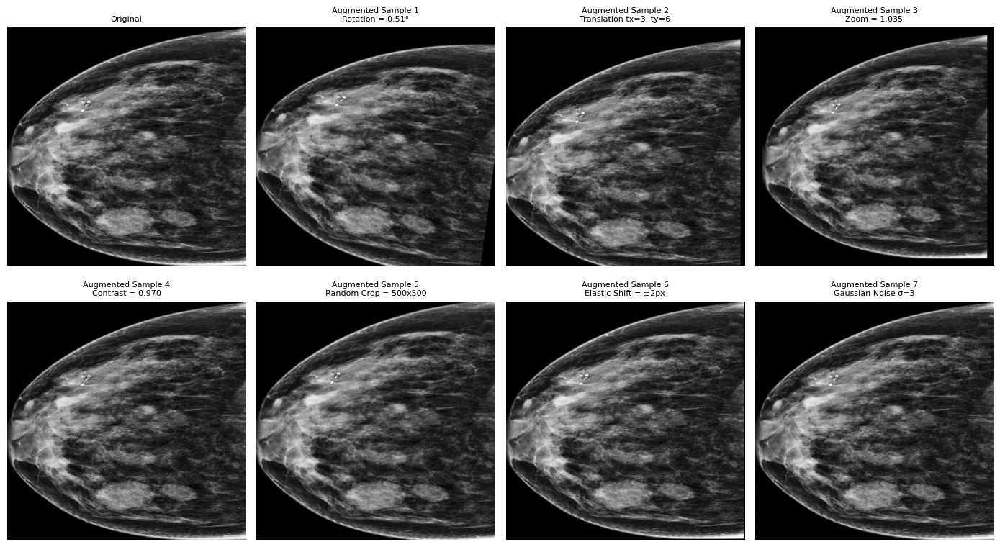

Benign 5% visualization saved!


In [56]:
# -----------------------------
# VISUALIZATION WITH ACTUAL VALUES (BENIGN)
# -----------------------------
print("Generating Benign visualization PNG...")

sample_img_path = os.path.join(input_dir, image_files[0])

img = load_img(sample_img_path, target_size=IMG_SIZE)
img = img_to_array(img)

# -----------------------------
# Generate ACTUAL values
# -----------------------------
rotation_value = np.random.uniform(-5, 5)

tx_value = int(np.random.uniform(-0.05, 0.05) * 512)
ty_value = int(np.random.uniform(-0.05, 0.05) * 512)

zoom_value = np.random.uniform(0.95, 1.05)

contrast_value = np.random.uniform(0.95, 1.05)

# -----------------------------
# Apply augmentations
# -----------------------------
rot_img = rotate(img.copy())
trans_img = translate(img.copy())
zoom_img = zoom(img.copy())
contrast_img = contrast(img.copy())

imgs = [

    ("Original", img),

    (f"Augmented Sample 1\nRotation = {rotation_value:.2f}°",
     rot_img),

    (f"Augmented Sample 2\nTranslation tx={tx_value}, ty={ty_value}",
     trans_img),

    (f"Augmented Sample 3\nZoom = {zoom_value:.3f}",
     zoom_img),

    (f"Augmented Sample 4\nContrast = {contrast_value:.3f}",
     contrast_img),

    ("Augmented Sample 5\nRandom Crop = 500x500",
     random_crop(img.copy())),

    ("Augmented Sample 6\nElastic Shift = ±2px",
     elastic_shift(img.copy())),

    ("Augmented Sample 7\nGaussian Noise σ=3",
     gaussian_noise(img.copy()))
]

fig, axes = plt.subplots(2, 4, figsize=(14, 8))

axes = axes.flatten()

for i, (title, im) in enumerate(imgs):

    axes[i].imshow(np.clip(im, 0, 255).astype(np.uint8),
                   cmap='gray')

    axes[i].set_title(title, fontsize=8)

    axes[i].axis('off')

plt.tight_layout()

plt.savefig(
    r"D:\Thesis_folder\plots_folder\benign_augmentation_visualization_5percent.pdf",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print("Benign 5% visualization saved!")

Generating Benign 7–10% visualization PNG...


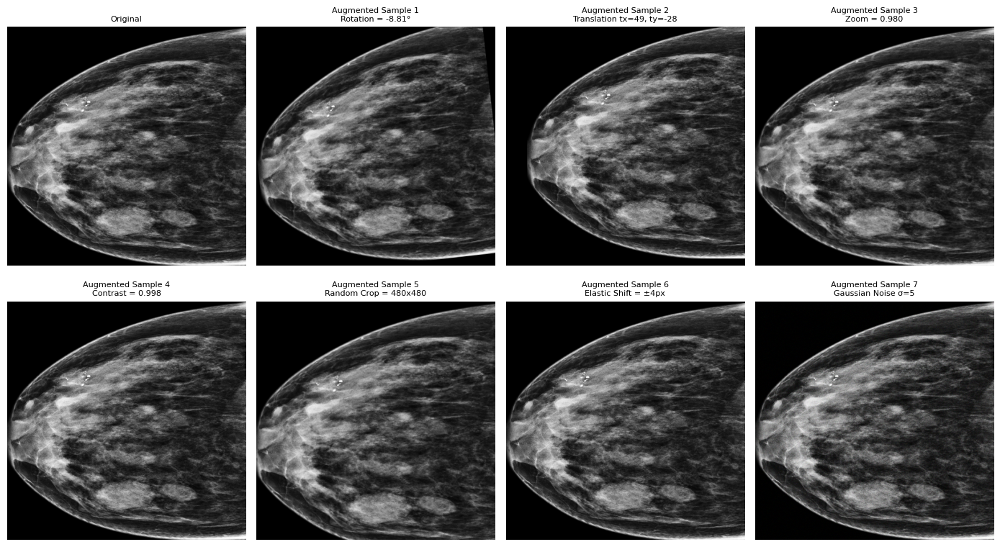

Benign 7–10% visualization saved!


In [57]:
print("Generating Benign 7–10% visualization PNG...")

rotation_value = np.random.uniform(-10, 10)

tx_value = int(np.random.uniform(-0.10, 0.10) * 512)
ty_value = int(np.random.uniform(-0.10, 0.10) * 512)

zoom_value = np.random.uniform(0.90, 1.10)

contrast_value = np.random.uniform(0.90, 1.10)

imgs = [

    ("Original", img),

    (f"Augmented Sample 1\nRotation = {rotation_value:.2f}°",
     rotate(img.copy())),

    (f"Augmented Sample 2\nTranslation tx={tx_value}, ty={ty_value}",
     translate(img.copy())),

    (f"Augmented Sample 3\nZoom = {zoom_value:.3f}",
     zoom(img.copy())),

    (f"Augmented Sample 4\nContrast = {contrast_value:.3f}",
     contrast(img.copy())),

    ("Augmented Sample 5\nRandom Crop = 480x480",
     random_crop(img.copy(), crop_size=(480, 480))),

    ("Augmented Sample 6\nElastic Shift = ±4px",
     elastic_shift(img.copy())),

    ("Augmented Sample 7\nGaussian Noise σ=5",
     gaussian_noise(img.copy()))
]

fig, axes = plt.subplots(2, 4, figsize=(14, 8))

axes = axes.flatten()

for i, (title, im) in enumerate(imgs):

    axes[i].imshow(np.clip(im, 0, 255).astype(np.uint8),
                   cmap='gray')

    axes[i].set_title(title, fontsize=8)

    axes[i].axis('off')

plt.tight_layout()

plt.savefig(
    r"D:\Thesis_folder\plots_folder\benign_augmentation_visualization_10percent.pdf",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print("Benign 7–10% visualization saved!")

In [58]:
print("Mammography Augmentation Pipeline Starting...")
print("For Normal")

import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing.image import load_img, img_to_array, save_img
from matplotlib.backends.backend_pdf import PdfPages

# -----------------------------
# Paths (ONLY CHANGE HERE)
# -----------------------------
input_dir = r"D:\Thesis_folder\classification_folders\Normal\raw_images"
output_dir = r"D:\Thesis_folder\classification_folders\Normal\preprocessed_images"
vis_pdf_path = r"D:\Thesis_folder\augmentation_visualization_normal.pdf"

os.makedirs(output_dir, exist_ok=True)

IMG_SIZE = (512, 512)

# -----------------------------
# Augmentation Functions
# (Same clinically safe settings)
# -----------------------------

def horizontal_flip(img):
    if np.random.rand() < 0.5:
        return cv2.flip(img, 1)
    return img


def rotate(img):
    # angle = np.random.uniform(-5, 5)
    angle = np.random.uniform(-10,10)
    h, w = img.shape[:2]
    M = cv2.getRotationMatrix2D((w//2, h//2), angle, 1.0)
    return cv2.warpAffine(img, M, (w, h))


def translate(img):
    h, w = img.shape[:2]
    # tx = int(np.random.uniform(-0.05, 0.05) * w)
    # ty = int(np.random.uniform(-0.05, 0.05) * h)
    tx = int(np.random.uniform(-0.10,0.10)*w)
    ty = int(np.random.uniform(-0.10,0.10)*h)
    M = np.float32([[1, 0, tx],
                    [0, 1, ty]])
    return cv2.warpAffine(img, M, (w, h))


def zoom(img):
    # zoom_factor = np.random.uniform(0.95, 1.05)
    zoom_factor = np.random.uniform(0.90,1.10)
    h, w = img.shape[:2]

    new_h, new_w = int(h * zoom_factor), int(w * zoom_factor)
    resized = cv2.resize(img, (new_w, new_h))

    if zoom_factor < 1.0:
        pad_h = (h - new_h) // 2
        pad_w = (w - new_w) // 2
        return cv2.copyMakeBorder(
            resized,
            pad_h, h-new_h-pad_h,
            pad_w, w-new_w-pad_w,
            cv2.BORDER_CONSTANT, value=0
        )

    start_h = (new_h - h) // 2
    start_w = (new_w - w) // 2
    return resized[start_h:start_h+h, start_w:start_w+w]


def contrast(img):
    # alpha = np.random.uniform(0.95, 1.05)
    alpha = np.random.uniform(0.90,1.10)
    return np.clip(alpha * img, 0, 255)


def random_crop(img, crop_size=(500, 500)):
    h, w = img.shape[:2]
    ch, cw = crop_size

    x = np.random.randint(0, w - cw + 1)
    y = np.random.randint(0, h - ch + 1)

    cropped = img[y:y+ch, x:x+cw]
    return cv2.resize(cropped, (w, h))


def elastic_shift(img):
    h, w = img.shape[:2]
    dx = np.random.randint(-2, 3)
    dy = np.random.randint(-2, 3)

    M = np.float32([[1, 0, dx],
                    [0, 1, dy]])
    return cv2.warpAffine(img, M, (w, h))


def gaussian_noise(img):
    noise = np.random.normal(0, 3, img.shape)
    return img + noise


def augment(img):
    img = horizontal_flip(img)
    img = rotate(img)
    img = translate(img)
    img = zoom(img)
    img = contrast(img)
    img = random_crop(img)
    img = elastic_shift(img)
    img = gaussian_noise(img)
    return img


# -----------------------------
# Load images
# -----------------------------
image_files = [
    f for f in os.listdir(input_dir)
    if f.lower().endswith(('.png', '.jpg', '.jpeg'))
]

print("Total images:", len(image_files))

# -----------------------------
# Generate 8000 images
# -----------------------------
target_images = 8000
count = 0

while count < target_images:

    for img_name in image_files:

        if count >= target_images:
            break

        img_path = os.path.join(input_dir, img_name)

        img = load_img(img_path, target_size=IMG_SIZE)
        img = img_to_array(img)

        augmented = augment(img)

        augmented = np.clip(augmented, 0, 255).astype(np.uint8)

        save_path = os.path.join(output_dir, f"normal_aug_{count}.png")
        save_img(save_path, augmented)

        count += 1

        if count % 100 == 0:
            print(f"{count} images generated")

print("Dataset augmentation completed for Normal!")

Mammography Augmentation Pipeline Starting...
For Normal
Total images: 5243
100 images generated
200 images generated
300 images generated
400 images generated
500 images generated
600 images generated
700 images generated
800 images generated
900 images generated
1000 images generated
1100 images generated
1200 images generated
1300 images generated
1400 images generated
1500 images generated
1600 images generated
1700 images generated
1800 images generated
1900 images generated
2000 images generated
2100 images generated
2200 images generated
2300 images generated
2400 images generated
2500 images generated
2600 images generated
2700 images generated
2800 images generated
2900 images generated
3000 images generated
3100 images generated
3200 images generated
3300 images generated
3400 images generated
3500 images generated
3600 images generated
3700 images generated
3800 images generated
3900 images generated
4000 images generated
4100 images generated
4200 images generated
4300 imag

Generating Normal 5% visualization PNG...


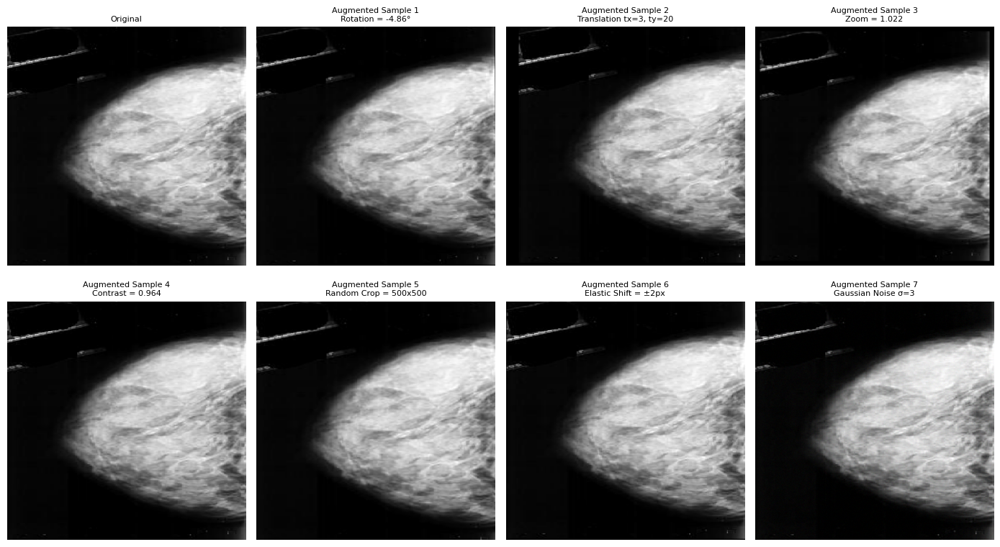

Normal 5% visualization saved!


In [59]:
print("Generating Normal 5% visualization PNG...")

rotation_value = np.random.uniform(-5, 5)

tx_value = int(np.random.uniform(-0.05, 0.05) * 512)
ty_value = int(np.random.uniform(-0.05, 0.05) * 512)

zoom_value = np.random.uniform(0.95, 1.05)

contrast_value = np.random.uniform(0.95, 1.05)

imgs = [

    ("Original", img),

    (f"Augmented Sample 1\nRotation = {rotation_value:.2f}°",
     rotate(img.copy())),

    (f"Augmented Sample 2\nTranslation tx={tx_value}, ty={ty_value}",
     translate(img.copy())),

    (f"Augmented Sample 3\nZoom = {zoom_value:.3f}",
     zoom(img.copy())),

    (f"Augmented Sample 4\nContrast = {contrast_value:.3f}",
     contrast(img.copy())),

    ("Augmented Sample 5\nRandom Crop = 500x500",
     random_crop(img.copy())),

    ("Augmented Sample 6\nElastic Shift = ±2px",
     elastic_shift(img.copy())),

    ("Augmented Sample 7\nGaussian Noise σ=3",
     gaussian_noise(img.copy()))
]

fig, axes = plt.subplots(2, 4, figsize=(14, 8))

axes = axes.flatten()

for i, (title, im) in enumerate(imgs):

    axes[i].imshow(np.clip(im, 0, 255).astype(np.uint8),
                   cmap='gray')

    axes[i].set_title(title, fontsize=8)

    axes[i].axis('off')

plt.tight_layout()

plt.savefig(
    r"D:\Thesis_folder\plots_folder\normal_augmentation_visualization_5percent.pdf",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print("Normal 5% visualization saved!")

Generating Normal 7–10% visualization PNG...


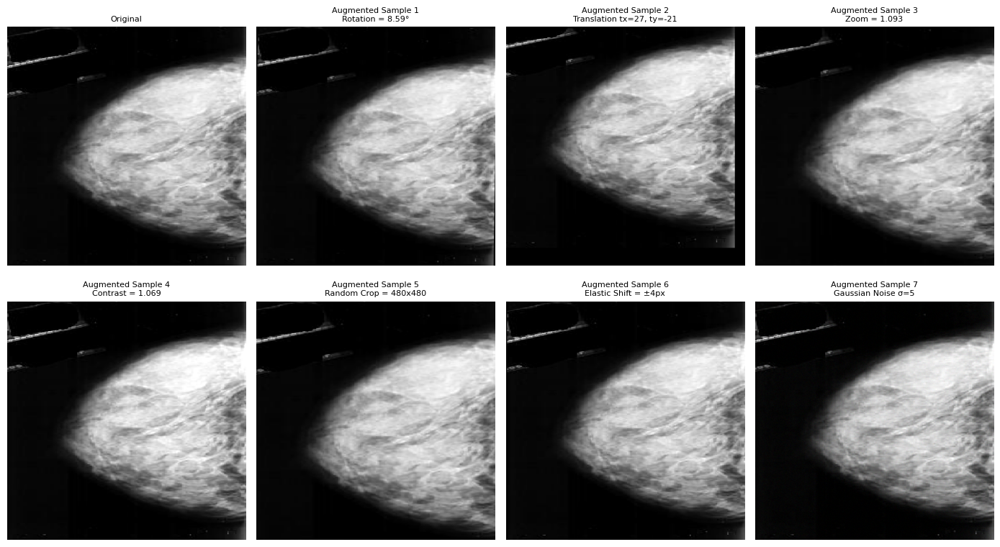

Normal 7–10% visualization saved!


In [60]:
print("Generating Normal 7–10% visualization PNG...")

rotation_value = np.random.uniform(-10, 10)

tx_value = int(np.random.uniform(-0.10, 0.10) * 512)
ty_value = int(np.random.uniform(-0.10, 0.10) * 512)

zoom_value = np.random.uniform(0.90, 1.10)

contrast_value = np.random.uniform(0.90, 1.10)

imgs = [

    ("Original", img),

    (f"Augmented Sample 1\nRotation = {rotation_value:.2f}°",
     rotate(img.copy())),

    (f"Augmented Sample 2\nTranslation tx={tx_value}, ty={ty_value}",
     translate(img.copy())),

    (f"Augmented Sample 3\nZoom = {zoom_value:.3f}",
     zoom(img.copy())),

    (f"Augmented Sample 4\nContrast = {contrast_value:.3f}",
     contrast(img.copy())),

    ("Augmented Sample 5\nRandom Crop = 480x480",
     random_crop(img.copy(), crop_size=(480, 480))),

    ("Augmented Sample 6\nElastic Shift = ±4px",
     elastic_shift(img.copy())),

    ("Augmented Sample 7\nGaussian Noise σ=5",
     gaussian_noise(img.copy()))
]

fig, axes = plt.subplots(2, 4, figsize=(14, 8))

axes = axes.flatten()

for i, (title, im) in enumerate(imgs):

    axes[i].imshow(np.clip(im, 0, 255).astype(np.uint8),
                   cmap='gray')

    axes[i].set_title(title, fontsize=8)

    axes[i].axis('off')

plt.tight_layout()

plt.savefig(
    r"D:\Thesis_folder\plots_folder\normal_augmentation_visualization_10percent.pdf",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print("Normal 7–10% visualization saved!")

Generating Malignant visualization PNG...


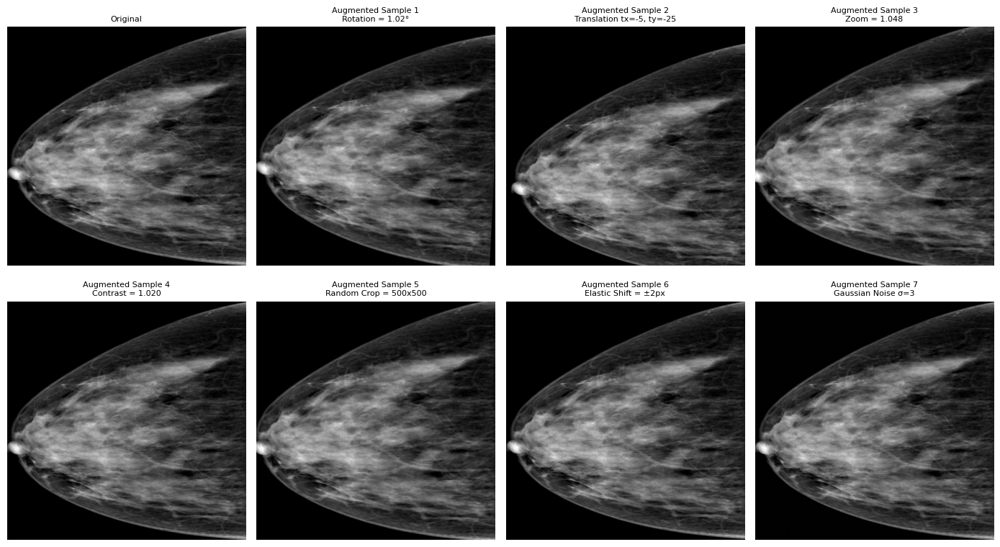

Malignant 5% visualization saved!


In [61]:
# -----------------------------
# VISUALIZATION WITH ACTUAL VALUES (MALIGNANT)
# -----------------------------
print("Generating Malignant visualization PNG...")

sample_img_path = os.path.join(input_dir, image_files[0])

img = load_img(sample_img_path, target_size=IMG_SIZE)
img = img_to_array(img)

# -----------------------------
# Generate ACTUAL values
# -----------------------------
rotation_value = np.random.uniform(-5, 5)

tx_value = int(np.random.uniform(-0.05, 0.05) * 512)
ty_value = int(np.random.uniform(-0.05, 0.05) * 512)

zoom_value = np.random.uniform(0.95, 1.05)

contrast_value = np.random.uniform(0.95, 1.05)

# -----------------------------
# Apply augmentations
# -----------------------------
rot_img = rotate(img.copy())
trans_img = translate(img.copy())
zoom_img = zoom(img.copy())
contrast_img = contrast(img.copy())

imgs = [

    ("Original", img),

    (f"Augmented Sample 1\nRotation = {rotation_value:.2f}°",
     rot_img),

    (f"Augmented Sample 2\nTranslation tx={tx_value}, ty={ty_value}",
     trans_img),

    (f"Augmented Sample 3\nZoom = {zoom_value:.3f}",
     zoom_img),

    (f"Augmented Sample 4\nContrast = {contrast_value:.3f}",
     contrast_img),

    ("Augmented Sample 5\nRandom Crop = 500x500",
     random_crop(img.copy())),

    ("Augmented Sample 6\nElastic Shift = ±2px",
     elastic_shift(img.copy())),

    ("Augmented Sample 7\nGaussian Noise σ=3",
     gaussian_noise(img.copy()))
]

fig, axes = plt.subplots(2, 4, figsize=(14, 8))

axes = axes.flatten()

for i, (title, im) in enumerate(imgs):

    axes[i].imshow(
        np.clip(im, 0, 255).astype(np.uint8),
        cmap='gray'
    )

    axes[i].set_title(title, fontsize=8)

    axes[i].axis('off')

plt.tight_layout()

plt.savefig(
    r"D:\Thesis_folder\plots_folder\malignant_augmentation_visualization_5percent.pdf",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print("Malignant 5% visualization saved!")

Generating Malignant 7–10% visualization PNG...


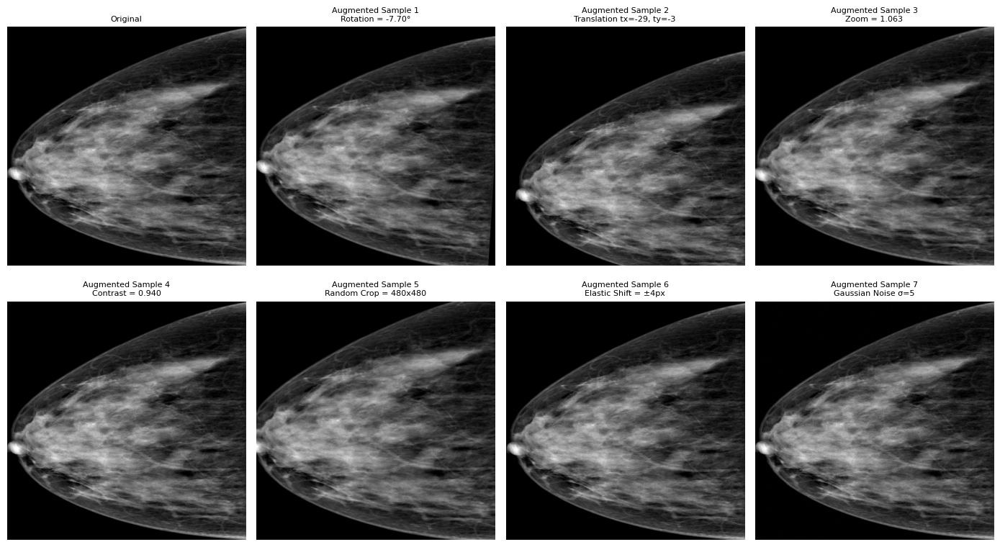

Malignant 7–10% visualization saved!


In [62]:
# -----------------------------
# VISUALIZATION WITH ACTUAL VALUES (MALIGNANT 7–10%)
# -----------------------------
print("Generating Malignant 7–10% visualization PNG...")

rotation_value = np.random.uniform(-10, 10)

tx_value = int(np.random.uniform(-0.10, 0.10) * 512)
ty_value = int(np.random.uniform(-0.10, 0.10) * 512)

zoom_value = np.random.uniform(0.90, 1.10)

contrast_value = np.random.uniform(0.90, 1.10)

imgs = [

    ("Original", img),

    (f"Augmented Sample 1\nRotation = {rotation_value:.2f}°",
     rotate(img.copy())),

    (f"Augmented Sample 2\nTranslation tx={tx_value}, ty={ty_value}",
     translate(img.copy())),

    (f"Augmented Sample 3\nZoom = {zoom_value:.3f}",
     zoom(img.copy())),

    (f"Augmented Sample 4\nContrast = {contrast_value:.3f}",
     contrast(img.copy())),

    ("Augmented Sample 5\nRandom Crop = 480x480",
     random_crop(img.copy(), crop_size=(480, 480))),

    ("Augmented Sample 6\nElastic Shift = ±4px",
     elastic_shift(img.copy())),

    ("Augmented Sample 7\nGaussian Noise σ=5",
     gaussian_noise(img.copy()))
]

fig, axes = plt.subplots(2, 4, figsize=(14, 8))

axes = axes.flatten()

for i, (title, im) in enumerate(imgs):

    axes[i].imshow(
        np.clip(im, 0, 255).astype(np.uint8),
        cmap='gray'
    )

    axes[i].set_title(title, fontsize=8)

    axes[i].axis('off')

plt.tight_layout()

plt.savefig(
    r"D:\Thesis_folder\plots_folder\malignant_augmentation_visualization_10percent.pdf",
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print("Malignant 7–10% visualization saved!")

Generating final dataset distribution pie chart...


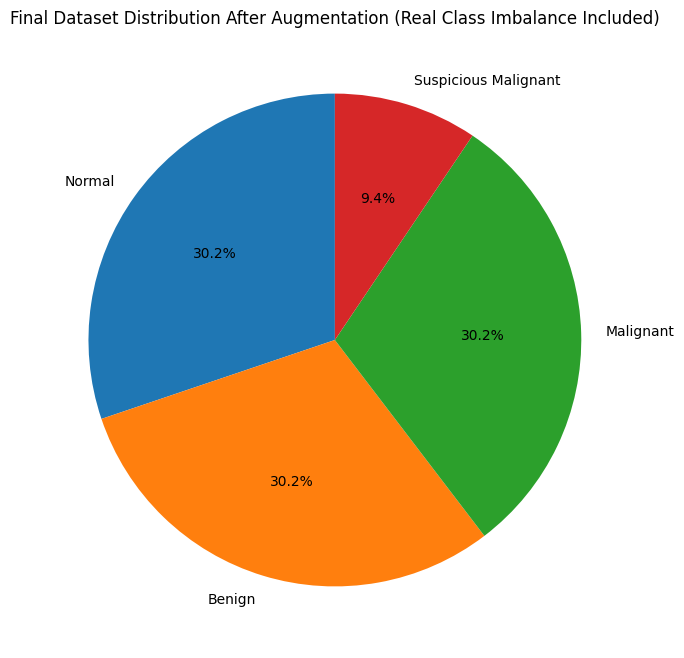

Saved at: D:\Thesis_folder\plots_folder\final_dataset_distribution.png


In [69]:
print("Generating final dataset distribution pie chart...")

import matplotlib.pyplot as plt

# -----------------------------
# Final dataset distribution
# -----------------------------
classes = ["Normal", "Benign", "Malignant", "Suspicious Malignant"]
counts = [8000, 8000, 8000, 2500]

# -----------------------------
# Create pie chart
# -----------------------------
plt.figure(figsize=(8, 8))

plt.pie(
    counts,
    labels=classes,
    autopct='%1.1f%%',
    startangle=90
)

plt.title("Final Dataset Distribution After Augmentation (Real Class Imbalance Included)")

# -----------------------------
# Save figure
# -----------------------------
output_path = r"D:\Thesis_folder\plots_folder\final_dataset_distribution.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')

plt.show()

print(f"Saved at: {output_path}")

In [70]:
# import torch

# print(torch.cuda.is_available())
# print("done")
# import torch

# print(torch.__version__)
# print(torch.version.cuda)
# print(torch.cuda.is_available())

In [71]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.backends.backend_pdf import PdfPages

from tensorflow.keras.preprocessing.image import (
    load_img,
    img_to_array
)

# ----------------------------------------
# SETTINGS
# ----------------------------------------
NUM_SAMPLES = 5
IMG_SIZE = (512, 512)

# ----------------------------------------
# PDF PATH
# ----------------------------------------
pdf_path = (
    r"D:\Thesis_folder\plots_folder"
    r"\augmentation_visual_review.pdf"
)

# ----------------------------------------
# DATASET PATHS
# ----------------------------------------
dataset_paths = {

    "Suspicious Malignant":
    r"D:\Thesis_folder\classification_folders\Suspicious_Malignant\preprocessed_images",

    "Malignant":
    r"D:\Thesis_folder\classification_folders\Malignant\preprocessed_images",

    "Normal":
    r"D:\Thesis_folder\classification_folders\Normal\preprocessed_images",

    "Benign":
    r"D:\Thesis_folder\classification_folders\Benign\preprocessed_images"
}

# ----------------------------------------
# CREATE PDF
# ----------------------------------------
with PdfPages(pdf_path) as pdf:

    # ------------------------------------
    # PROCESS EACH CLASS
    # ------------------------------------
    for class_name, input_dir in dataset_paths.items():

        print(f"\nProcessing {class_name}...")

        image_files = os.listdir(input_dir)

        selected_images = np.random.choice(
            image_files,
            NUM_SAMPLES,
            replace=False
        )

        for idx, img_name in enumerate(selected_images):

            print(
                f"{class_name} "
                f"{idx+1}/{NUM_SAMPLES}"
            )

            sample_img_path = os.path.join(
                input_dir,
                img_name
            )

            img = load_img(
                sample_img_path,
                target_size=IMG_SIZE
            )

            img = img_to_array(img)

            fig, axes = plt.subplots(
                3,
                8,
                figsize=(22, 10)
            )

            percentages = [5, 7, 10]

            for row, percent in enumerate(percentages):

                rotation_value = np.random.uniform(
                    -percent,
                    percent
                )

                tx_value = int(
                    np.random.uniform(
                        -percent / 100,
                        percent / 100
                    ) * 512
                )

                ty_value = int(
                    np.random.uniform(
                        -percent / 100,
                        percent / 100
                    ) * 512
                )

                zoom_value = np.random.uniform(
                    1 - percent / 100,
                    1 + percent / 100
                )

                contrast_value = np.random.uniform(
                    1 - percent / 100,
                    1 + percent / 100
                )

                imgs = [

                    ("Original", img),

                    (
                        f"Rotation\n"
                        f"{rotation_value:.2f}°",
                        rotate(img.copy())
                    ),

                    (
                        f"Translation\n"
                        f"{tx_value},{ty_value}",
                        translate(img.copy())
                    ),

                    (
                        f"Zoom\n"
                        f"{zoom_value:.3f}",
                        zoom(img.copy())
                    ),

                    (
                        f"Contrast\n"
                        f"{contrast_value:.3f}",
                        contrast(img.copy())
                    ),

                    (
                        "Random Crop\n480x480",
                        random_crop(
                            img.copy(),
                            crop_size=(480, 480)
                        )
                    ),

                    (
                        "Elastic Shift\n±4px",
                        elastic_shift(
                            img.copy()
                        )
                    ),

                    (
                        "Gaussian Noise\nσ=5",
                        gaussian_noise(
                            img.copy()
                        )
                    )
                ]

                for col, (title, im) in enumerate(imgs):

                    axes[row, col].imshow(
                        np.clip(im, 0, 255)
                        .astype(np.uint8),
                        cmap='gray'
                    )

                    axes[row, col].set_title(
                        f"{percent}%\n{title}",
                        fontsize=7
                    )

                    axes[row, col].axis('off')

            plt.suptitle(
                f"{class_name} - Sample {idx+1}",
                fontsize=16
            )

            plt.tight_layout()

            # -----------------------------
            # SAVE CURRENT PAGE TO PDF
            # -----------------------------
            pdf.savefig(fig)

            plt.close(fig)

# ----------------------------------------
# DONE
# ----------------------------------------
print("\nDone!")
print(pdf_path)


Processing Suspicious Malignant...
Suspicious Malignant 1/5
Suspicious Malignant 2/5
Suspicious Malignant 3/5
Suspicious Malignant 4/5
Suspicious Malignant 5/5

Processing Malignant...
Malignant 1/5
Malignant 2/5
Malignant 3/5
Malignant 4/5
Malignant 5/5

Processing Normal...
Normal 1/5
Normal 2/5
Normal 3/5
Normal 4/5
Normal 5/5

Processing Benign...
Benign 1/5
Benign 2/5
Benign 3/5
Benign 4/5
Benign 5/5

Done!
D:\Thesis_folder\plots_folder\augmentation_visual_review.pdf


In [1]:
print("hello")

hello


In [2]:
# EfficientNetB2 Model Training (Balanced Data)
print("start")

import os
import shutil
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import EfficientNetB2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.metrics import Recall, Precision

from sklearn.metrics import classification_report, confusion_matrix

print("Done1")


start
Done1


In [73]:
print("start")

balanced_dataset = r"D:\Thesis_folder\Balanced_dataset"

os.makedirs(balanced_dataset, exist_ok=True)

class_paths = {

    "Benign":
    r"D:\Thesis_folder\classification_folders\Benign\preprocessed_images",

    "Malignant":
    r"D:\Thesis_folder\classification_folders\Malignant\preprocessed_images",

    "Normal":
    r"D:\Thesis_folder\classification_folders\Normal\preprocessed_images",

    "Suspicious_Malignant":
    r"D:\Thesis_folder\classification_folders\Suspicious_Malignant\preprocessed_images"
}

for class_name, path in class_paths.items():

    destination = os.path.join(balanced_dataset, class_name)

    if os.path.exists(destination):
        shutil.rmtree(destination)

    shutil.copytree(path, destination)

print("Balanced dataset ready")

start
Balanced dataset ready


In [74]:
print("start")

IMAGE_SIZE = (260,260)
BATCH_SIZE = 16
EPOCHS = 30

print("Done")

start
Done


In [75]:
print("start")

train_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2,

    rotation_range=25,

    zoom_range=0.25,

    horizontal_flip=True,

    width_shift_range=0.15,

    height_shift_range=0.15,

    brightness_range=[0.8,1.2],

    fill_mode='nearest'
)

print("done")

start
done


In [76]:
print("start")

train_generator = train_datagen.flow_from_directory(

    balanced_dataset,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training',

    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(

    balanced_dataset,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation',

    shuffle=False
)

print("Done")

start
Found 21348 images belonging to 4 classes.
Found 5336 images belonging to 4 classes.
Done


In [77]:
print("start")

base_model = EfficientNetB2(

    weights='imagenet',

    include_top=False,

    input_shape=(260,260,3)

)

base_model.trainable = False

print("done")

start
31790344/31790344 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
done


In [78]:
print("start")

model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    BatchNormalization(),

    Dropout(0.5),

    Dense(512, activation='relu'),

    BatchNormalization(),

    Dropout(0.4),

    Dense(256, activation='relu'),

    Dropout(0.3),

    Dense(4, activation='softmax')
])

print("Done")

start
Done


In [79]:
print("start")

model.compile(

    optimizer=Adam(learning_rate=0.0003),

    loss='categorical_crossentropy',

    metrics=[

        'accuracy',

        Recall(name='recall'),

        Precision(name='precision')
    ]
)

model.summary()

print("Done")

start


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ efficientnetb2 (Functional)          │ (None, 9, 9, 1408)          │       7,768,569 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d             │ (None, 1408)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 1408)                │           5,632 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 1408)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         721,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 512)                 │           2,048 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 8,630,013 (32.92 MB)

 Trainable params: 857,604 (3.27 MB)

 Non-trainable params: 7,772,409 (29.65 MB)

Done


In [80]:
print("start")

early_stop = EarlyStopping(

    monitor='val_accuracy',

    patience=7,

    restore_best_weights=True,

    mode='max'
)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=3,

    min_lr=0.000001
)

checkpoint = ModelCheckpoint(

    "best_efficientnetb2_model.keras",

    monitor='val_accuracy',

    save_best_only=True,

    mode='max'
)

print("done")

start
done


In [81]:
print("start")

history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=15,

    callbacks=[early_stop, reduce_lr, checkpoint]
)

print("Done")

start
Epoch 1/15
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 1417s 1s/step - accuracy: 0.3059 - loss: 1.6381 - precision: 0.3043 - recall: 0.1621 - val_accuracy: 0.2738 - val_loss: 1.3106 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 3.0000e-04
Epoch 2/15
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 1137s 852ms/step - accuracy: 0.3224 - loss: 1.4115 - precision: 0.3405 - recall: 0.0928 - val_accuracy: 0.2944 - val_loss: 1.3101 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 3.0000e-04
Epoch 3/15
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 3072s 2s/step - accuracy: 0.3394 - loss: 1.3399 - precision: 0.4036 - recall: 0.0532 - val_accuracy: 0.2924 - val_loss: 1.3218 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 3.0000e-04
Epoch 4/15
1335/1335 ━━━━━━━━━━━━━━━━━━━━ 1456s 1s/step - accuracy: 0.3519 - loss: 1.3075 - precision: 0.5316 - recall: 0.0469 - val_accuracy: 0.2680 - val_loss: 1.3219 - val_precision: 0.1429 - val_recall: 1.8741e-04 - learning_rate: 3.0000

In [20]:
# ==========================================================
# IMPORTS
# ==========================================================
print("start")

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    Callback
)

print("done1")

start
done1


In [33]:
# ==========================================================
# PARAMETERS
# ==========================================================
print("start")

DATASET_PATH = r"D:\Thesis_folder\Balanced_dataset"

IMAGE_SIZE = (256,256)

BATCH_SIZE = 16

EPOCHS = 15

print("done1")

start
done1


In [34]:
# ==========================================================
# DATA GENERATORS
# ==========================================================
print("start")

train_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    validation_split=0.30,

    rotation_range=15,

    zoom_range=0.15,

    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    validation_split=0.30
)

print("done1")

start
done1


In [35]:
# ==========================================================
# TRAIN
# ==========================================================
print("start")

train_generator = train_datagen.flow_from_directory(

    DATASET_PATH,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training'
)

print("done1")


start
Found 18679 images belonging to 4 classes.
done1


In [36]:
# ==========================================================
# VALIDATION
# ==========================================================
print("start")

validation_generator = valid_datagen.flow_from_directory(

    DATASET_PATH,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation',

    shuffle=False
)

print("done1")


start
Found 8005 images belonging to 4 classes.
done1


In [37]:
# ==========================================================
# MODEL
# ==========================================================
print("start")

base_model = DenseNet121(

    weights='imagenet',

    include_top=False,

    input_shape=(256,256,3)
)

base_model.trainable = False

model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    BatchNormalization(),

    Dropout(0.4),

    Dense(256, activation='relu'),

    Dropout(0.3),

    Dense(4, activation='softmax')
])

print("done1")


start
done1


In [38]:
# ==========================================================
# CALLBACKS
# ==========================================================
print("start")

early_stop = EarlyStopping(

    monitor='val_accuracy',

    patience=5,

    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=3
)

checkpoint = ModelCheckpoint(

    "DenseNet121_best.keras",

    save_best_only=True
)

print("done")

start
done


In [39]:
# ==========================================================
# SHOW LEARNING RATE
# ==========================================================
print("start")
class PrintLearningRate(Callback):

    def on_epoch_end(self, epoch, logs=None):

        lr = self.model.optimizer.learning_rate.numpy()

        print(f"\nEpoch {epoch+1} Learning Rate : {lr}")


lr_callback = PrintLearningRate()

print("done1")


start
done1


In [40]:
# ==========================================================
# COMPILE
# ==========================================================
print("start")

model.compile(

    optimizer=Adam(0.0001),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

print("done1")

start
done1


In [41]:
# ==========================================================
# TRAINING
# ==========================================================
print("start")

history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=EPOCHS,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint,
        lr_callback
    ]
)
# ==========================================================
# EVALUATION
# ==========================================================
train_loss, train_acc = model.evaluate(train_generator)

test_loss, test_acc = model.evaluate(validation_generator)

print(f"\nTraining Accuracy : {train_acc*100:.2f}%")

print(f"Testing Accuracy  : {test_acc*100:.2f}%")


# ==========================================================
# PRECISION, RECALL, F1-SCORE
# ==========================================================
print("\nCalculating Precision, Recall, F1-score...")

predictions = model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = validation_generator.classes

class_names = list(validation_generator.class_indices.keys())

print("\nClassification Report:\n")

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

print("done1")

start
Epoch 1/15
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 0s 863ms/step - accuracy: 0.6452 - loss: 0.8557
Epoch 1 Learning Rate : 9.999999747378752e-05
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 1451s 1s/step - accuracy: 0.7326 - loss: 0.6414 - val_accuracy: 0.8411 - val_loss: 0.3444 - learning_rate: 1.0000e-04
Epoch 2/15
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 0s 849ms/step - accuracy: 0.7970 - loss: 0.4738
Epoch 2 Learning Rate : 9.999999747378752e-05
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 1413s 1s/step - accuracy: 0.8045 - loss: 0.4552 - val_accuracy: 0.8665 - val_loss: 0.2917 - learning_rate: 1.0000e-04
Epoch 3/15
1167/1168 ━━━━━━━━━━━━━━━━━━━━ 0s 926ms/step - accuracy: 0.8148 - loss: 0.4183
Epoch 3 Learning Rate : 9.999999747378752e-05
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 1527s 1s/step - accuracy: 0.8167 - loss: 0.4154 - val_accuracy: 0.8651 - val_loss: 0.2918 - learning_rate: 1.0000e-04
Epoch 4/15
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 0s 895ms/step - accuracy: 0.8252 - loss: 0.3909
Epoch 4 Learning Rate : 9.999999747378752e-05
116

In [43]:
# For imbalanced dataset for DenseNet121
print("start")

imbalanced_dataset = r"D:\Thesis_folder\Imbalanced_dataset"

os.makedirs(imbalanced_dataset, exist_ok=True)

class_paths = {

    "Benign":
    r"D:\Thesis_folder\classification_folders\Benign\raw_images",

    "Malignant":
    r"D:\Thesis_folder\classification_folders\Malignant\raw_images",

    "Normal":
    r"D:\Thesis_folder\classification_folders\Normal\raw_images",

    "Suspicious_Malignant":
    r"D:\Thesis_folder\classification_folders\Suspicious_Malignant\raw_images"
}

for class_name, path in class_paths.items():

    destination = os.path.join(imbalanced_dataset, class_name)

    if os.path.exists(destination):
        shutil.rmtree(destination)

    shutil.copytree(path, destination)

print("ImBalanced dataset ready")

start
ImBalanced dataset ready


In [44]:
# ==========================================================
# IMPORTS
# ==========================================================
print("start")

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    Callback
)

print("done1")

start
done1


In [45]:
# ==========================================================
# PARAMETERS
# ==========================================================
print("start")

DATASET_PATH = r"D:\Thesis_folder\Imbalanced_dataset"

IMAGE_SIZE = (256,256)

BATCH_SIZE = 16

EPOCHS = 15

print("done1")

start
done1


In [46]:
# ==========================================================
# DATA GENERATORS
# ==========================================================
print("start")

train_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    validation_split=0.30,

    rotation_range=15,

    zoom_range=0.15,

    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    validation_split=0.30
)

print("done1")

start
done1


In [47]:
# ==========================================================
# TRAIN
# ==========================================================
print("start")

train_generator = train_datagen.flow_from_directory(

    DATASET_PATH,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training'
)

print("done1")


start
Found 13814 images belonging to 4 classes.
done1


In [48]:
# ==========================================================
# VALIDATION
# ==========================================================
print("start")

validation_generator = valid_datagen.flow_from_directory(

    DATASET_PATH,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation',

    shuffle=False
)

print("done1")


start
Found 5917 images belonging to 4 classes.
done1


In [49]:
# ==========================================================
# MODEL
# ==========================================================
print("start")

base_model = DenseNet121(

    weights='imagenet',

    include_top=False,

    input_shape=(256,256,3)
)

base_model.trainable = False

model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    BatchNormalization(),

    Dropout(0.4),

    Dense(256, activation='relu'),

    Dropout(0.3),

    Dense(4, activation='softmax')
])

print("done1")


start
done1


In [50]:
# ==========================================================
# CALLBACKS
# ==========================================================
print("start")

early_stop = EarlyStopping(

    monitor='val_accuracy',

    patience=5,

    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=3
)

checkpoint = ModelCheckpoint(

    "DenseNet121_best.keras",

    save_best_only=True
)

print("done")

start
done


In [51]:
# ==========================================================
# SHOW LEARNING RATE
# ==========================================================
print("start")
class PrintLearningRate(Callback):

    def on_epoch_end(self, epoch, logs=None):

        lr = self.model.optimizer.learning_rate.numpy()

        print(f"\nEpoch {epoch+1} Learning Rate : {lr}")


lr_callback = PrintLearningRate()

print("done1")


start
done1


In [52]:
# ==========================================================
# COMPILE
# ==========================================================
print("start")

model.compile(

    optimizer=Adam(0.0001),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

print("done1")

start
done1


In [53]:
# ==========================================================
# TRAINING
# ==========================================================
print("start")

history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=EPOCHS,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint,
        lr_callback
    ]
)
# ==========================================================
# EVALUATION
# ==========================================================
train_loss, train_acc = model.evaluate(train_generator)

test_loss, test_acc = model.evaluate(validation_generator)

print(f"\nTraining Accuracy : {train_acc*100:.2f}%")

print(f"Testing Accuracy  : {test_acc*100:.2f}%")


# ==========================================================
# PRECISION, RECALL, F1-SCORE
# ==========================================================
print("\nCalculating Precision, Recall, F1-score...")

predictions = model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = validation_generator.classes

class_names = list(validation_generator.class_indices.keys())

print("\nClassification Report:\n")

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

print("done1")

start
Epoch 1/15
864/864 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4678 - loss: 1.1989
Epoch 1 Learning Rate : 9.999999747378752e-05
864/864 ━━━━━━━━━━━━━━━━━━━━ 1342s 2s/step - accuracy: 0.5353 - loss: 1.0426 - val_accuracy: 0.5743 - val_loss: 1.5586 - learning_rate: 1.0000e-04
Epoch 2/15
864/864 ━━━━━━━━━━━━━━━━━━━━ 0s 907ms/step - accuracy: 0.6131 - loss: 0.8620
Epoch 2 Learning Rate : 9.999999747378752e-05
864/864 ━━━━━━━━━━━━━━━━━━━━ 1113s 1s/step - accuracy: 0.6147 - loss: 0.8428 - val_accuracy: 0.5952 - val_loss: 1.6318 - learning_rate: 1.0000e-04
Epoch 3/15
864/864 ━━━━━━━━━━━━━━━━━━━━ 0s 5s/step - accuracy: 0.6344 - loss: 0.8016
Epoch 3 Learning Rate : 9.999999747378752e-05
864/864 ━━━━━━━━━━━━━━━━━━━━ 4707s 5s/step - accuracy: 0.6372 - loss: 0.7819 - val_accuracy: 0.5974 - val_loss: 1.8239 - learning_rate: 1.0000e-04
Epoch 4/15
864/864 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6505 - loss: 0.7502
Epoch 4 Learning Rate : 1.9999999494757503e-05
864/864 ━━━━━━━━━━━━━━━━━

In [ ]:
# MobileNetV2 start from here for imBalanced dataset


In [54]:
# ==========================================================
# IMPORTS
# ==========================================================
print("start")

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    Callback
)

print("done1")

start
done1


In [68]:
# ==========================================================
# PARAMETERS
# ==========================================================
print("start")

DATASET_PATH = r"D:\Thesis_folder\Imbalanced_dataset"

IMAGE_SIZE = (256,256)

BATCH_SIZE = 16

EPOCHS = 15

print("done1")

start
done1


In [56]:
# ==========================================================
# DATA GENERATORS
# ==========================================================
print("start")

train_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    validation_split=0.30,

    rotation_range=15,

    zoom_range=0.15,

    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    validation_split=0.30
)

print("done1")

start
done1


In [57]:
# ==========================================================
# TRAIN
# ==========================================================
print("start")

train_generator = train_datagen.flow_from_directory(

    DATASET_PATH,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training'
)

print("done1")

start
Found 18679 images belonging to 4 classes.
done1


In [58]:
# ==========================================================
# VALIDATION
# ==========================================================
print("start")

validation_generator = valid_datagen.flow_from_directory(

    DATASET_PATH,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation',

    shuffle=False
)

print("done1")

start
Found 8005 images belonging to 4 classes.
done1


In [59]:
# ==========================================================
# MODEL
# ==========================================================
print("start")

base_model = MobileNetV2(

    weights='imagenet',

    include_top=False,

    input_shape=(256,256,3)
)

base_model.trainable = False

model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    BatchNormalization(),

    Dropout(0.4),

    Dense(256, activation='relu'),

    Dropout(0.3),

    Dense(4, activation='softmax')
])

print("done1")

start


C:\Users\USER\AppData\Local\Temp\ipykernel_3436\4128122971.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
done1


In [60]:
# ==========================================================
# CALLBACKS
# ==========================================================
print("start")

early_stop = EarlyStopping(

    monitor='val_accuracy',

    patience=5,

    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=3
)

checkpoint = ModelCheckpoint(

    "MobileNetV2_best.keras",

    save_best_only=True
)

print("done1")


start
done1


In [61]:
# ==========================================================
# SHOW LEARNING RATE
# ==========================================================
print("start")

class PrintLearningRate(Callback):

    def on_epoch_end(self, epoch, logs=None):

        lr = self.model.optimizer.learning_rate.numpy()

        print(f"\nEpoch {epoch+1} Learning Rate : {lr}")


lr_callback = PrintLearningRate()

print("done1")


start
done1


In [62]:
# ==========================================================
# COMPILE
# ==========================================================
print("start")

model.compile(

    optimizer=Adam(0.0001),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

print("done1")

start
done1


In [64]:
# ==========================================================
# TRAINING
# ==========================================================
print("start")

history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=EPOCHS,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint,
        lr_callback
    ]
)
# ==========================================================
# PRECISION, RECALL, F1-SCORE
# ==========================================================
print("\nCalculating Precision, Recall, F1-score...")

predictions = model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = validation_generator.classes

class_names = list(validation_generator.class_indices.keys())

print("\nClassification Report:\n")

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

print("done1 with MobileNetV2 balanced data")


start
Epoch 1/15
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 0s 558ms/step - accuracy: 0.6137 - loss: 1.0368
Epoch 1 Learning Rate : 9.999999747378752e-05
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 860s 736ms/step - accuracy: 0.6934 - loss: 0.8132 - val_accuracy: 0.8079 - val_loss: 0.4717 - learning_rate: 1.0000e-04
Epoch 2/15
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.7567 - loss: 0.6135
Epoch 2 Learning Rate : 9.999999747378752e-05
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 666s 570ms/step - accuracy: 0.7660 - loss: 0.5787 - val_accuracy: 0.8250 - val_loss: 0.3964 - learning_rate: 1.0000e-04
Epoch 3/15
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 0s 527ms/step - accuracy: 0.7881 - loss: 0.5050
Epoch 3 Learning Rate : 9.999999747378752e-05
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 774s 663ms/step - accuracy: 0.7892 - loss: 0.5020 - val_accuracy: 0.8345 - val_loss: 0.3571 - learning_rate: 1.0000e-04
Epoch 4/15
1168/1168 ━━━━━━━━━━━━━━━━━━━━ 0s 434ms/step - accuracy: 0.7997 - loss: 0.4740
Epoch 4 Learning Rate : 9.999999747378752e-

In [66]:
train_loss, train_acc = model.evaluate(train_generator)

test_loss, test_acc = model.evaluate(validation_generator)

print(f"\nTraining Accuracy : {train_acc*100:.2f}%")

print(f"Testing Accuracy  : {test_acc*100:.2f}%")
print("Balanced data for MobileNet V2 accuracy done")

1168/1168 ━━━━━━━━━━━━━━━━━━━━ 489s 419ms/step - accuracy: 0.8802 - loss: 0.2686
501/501 ━━━━━━━━━━━━━━━━━━━━ 147s 293ms/step - accuracy: 0.8593 - loss: 0.3227

Training Accuracy : 88.02%
Testing Accuracy  : 85.93%
Balanced data for MobileNet V2 accuracy done


In [67]:
# For Imbalanced data model training for MobileNetv2
# ==========================================================
# IMPORTS
# ==========================================================
print("start")

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.metrics import classification_report

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import (
    Dense,
    Dropout,
    GlobalAveragePooling2D,
    BatchNormalization
)

from tensorflow.keras.optimizers import Adam

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau,
    ModelCheckpoint,
    Callback
)

print("done1")

start
done1


In [69]:
# ==========================================================
# PARAMETERS
# ==========================================================
print("start")

DATASET_PATH = r"D:\Thesis_folder\Imbalanced_dataset"

IMAGE_SIZE = (256,256)

BATCH_SIZE = 16

EPOCHS = 15

print("done1")

start
done1


In [70]:
# ==========================================================
# DATA GENERATORS
# ==========================================================
print("start")

train_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    validation_split=0.30,

    rotation_range=15,

    zoom_range=0.15,

    horizontal_flip=True
)

valid_datagen = ImageDataGenerator(

    preprocessing_function=preprocess_input,

    validation_split=0.30
)

print("done1")

start
done1


In [71]:
# ==========================================================
# TRAIN
# ==========================================================
print("start")

train_generator = train_datagen.flow_from_directory(

    DATASET_PATH,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training'
)

print("done1")

start
Found 13814 images belonging to 4 classes.
done1


In [72]:
# ==========================================================
# VALIDATION
# ==========================================================
print("start")

validation_generator = valid_datagen.flow_from_directory(

    DATASET_PATH,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation',

    shuffle=False
)

print("done1")

start
Found 5917 images belonging to 4 classes.
done1


In [73]:
# ==========================================================
# MODEL
# ==========================================================
print("start")

base_model = MobileNetV2(

    weights='imagenet',

    include_top=False,

    input_shape=(256,256,3)
)

base_model.trainable = False

model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    BatchNormalization(),

    Dropout(0.4),

    Dense(256, activation='relu'),

    Dropout(0.3),

    Dense(4, activation='softmax')
])

print("done1")

start


C:\Users\USER\AppData\Local\Temp\ipykernel_3436\4128122971.py:6: UserWarning: `input_shape` is undefined or non-square, or `rows` is not in [96, 128, 160, 192, 224]. Weights for input shape (224, 224) will be loaded as the default.
  base_model = MobileNetV2(


done1


In [74]:
# ==========================================================
# CALLBACKS
# ==========================================================
print("start")

early_stop = EarlyStopping(

    monitor='val_accuracy',

    patience=5,

    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=3
)

checkpoint = ModelCheckpoint(

    "MobileNetV2_best.keras",

    save_best_only=True
)

print("done1")


start
done1


In [75]:
# ==========================================================
# SHOW LEARNING RATE
# ==========================================================
print("start")

class PrintLearningRate(Callback):

    def on_epoch_end(self, epoch, logs=None):

        lr = self.model.optimizer.learning_rate.numpy()

        print(f"\nEpoch {epoch+1} Learning Rate : {lr}")


lr_callback = PrintLearningRate()

print("done1")


start
done1


In [76]:
# ==========================================================
# COMPILE
# ==========================================================
print("start")

model.compile(

    optimizer=Adam(0.0001),

    loss='categorical_crossentropy',

    metrics=['accuracy']
)

print("done1")

start
done1


In [77]:
# ==========================================================
# TRAINING
# ==========================================================
print("start")

history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=EPOCHS,

    callbacks=[
        early_stop,
        reduce_lr,
        checkpoint,
        lr_callback
    ]
)

train_loss, train_acc = model.evaluate(train_generator)

test_loss, test_acc = model.evaluate(validation_generator)

print(f"\nTraining Accuracy : {train_acc*100:.2f}%")

print(f"Testing Accuracy  : {test_acc*100:.2f}%")


# ==========================================================
# PRECISION, RECALL, F1-SCORE
# ==========================================================
print("\nCalculating Precision, Recall, F1-score...")

predictions = model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = validation_generator.classes

class_names = list(validation_generator.class_indices.keys())

print("\nClassification Report:\n")

print(
    classification_report(
        true_classes,
        predicted_classes,
        target_names=class_names
    )
)

print("done1 with MobileNetV2 imbalanced data")


start
Epoch 1/15
864/864 ━━━━━━━━━━━━━━━━━━━━ 0s 694ms/step - accuracy: 0.4771 - loss: 1.5050
Epoch 1 Learning Rate : 9.999999747378752e-05
864/864 ━━━━━━━━━━━━━━━━━━━━ 827s 951ms/step - accuracy: 0.5505 - loss: 1.2039 - val_accuracy: 0.5565 - val_loss: 2.2258 - learning_rate: 1.0000e-04
Epoch 2/15
864/864 ━━━━━━━━━━━━━━━━━━━━ 0s 560ms/step - accuracy: 0.6067 - loss: 0.9735

KeyboardInterrupt: 

In [80]:
# RenNet50 Model Trainig from here (For Balancing data)
print("start")
import os
import shutil
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.metrics import Recall

from sklearn.metrics import classification_report, confusion_matrix
print("Done")

start
Done


In [81]:
print("start")
balanced_dataset = r"D:\Thesis_folder\Balanced_dataset"

os.makedirs(balanced_dataset, exist_ok=True)

class_paths = {

    "Benign":
    r"D:\Thesis_folder\classification_folders\Benign\preprocessed_images",

    "Malignant":
    r"D:\Thesis_folder\classification_folders\Malignant\preprocessed_images",

    "Normal":
    r"D:\Thesis_folder\classification_folders\Normal\preprocessed_images",

    "Suspicious_Malignant":
    r"D:\Thesis_folder\classification_folders\Suspicious_Malignant\preprocessed_images"
}

for class_name, path in class_paths.items():

    destination = os.path.join(balanced_dataset, class_name)

    if os.path.exists(destination):
        shutil.rmtree(destination)

    shutil.copytree(path, destination)

print("Balanced dataset ready")

start
Balanced dataset ready


In [83]:
# Image parameters
print("start")

IMAGE_SIZE = (224,224)

BATCH_SIZE = 64

EPOCHS = 10
print("done")

start
done


In [84]:
# Data Generator
print("start")
train_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2,

    rotation_range=20,

    zoom_range=0.2,

    horizontal_flip=True,

    width_shift_range=0.1,

    height_shift_range=0.1
)
print("done")

start
done


In [85]:
# Load Dataset
print("start")
train_generator = train_datagen.flow_from_directory(

    balanced_dataset,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='training'

)

validation_generator = train_datagen.flow_from_directory(

    balanced_dataset,

    target_size=IMAGE_SIZE,

    batch_size=BATCH_SIZE,

    class_mode='categorical',

    subset='validation'

)
print("Done")

start
Found 21348 images belonging to 4 classes.
Found 5336 images belonging to 4 classes.
Done


In [86]:
# Building ResNet50 Model
# Recall Optimization
print("start")
base_model = ResNet50(

    weights='imagenet',

    include_top=False,

    input_shape=(224,224,3)

)

base_model.trainable = False
print("done")

start
done


In [87]:
# Final Model
print("start")
model = Sequential([

    base_model,

    GlobalAveragePooling2D(),

    Dropout(0.5),

    Dense(512, activation='relu'),

    Dropout(0.3),

    Dense(256, activation='relu'),

    Dropout(0.2),

    Dense(4, activation='softmax')
])
print("Done")

start
Done


In [88]:
# Compile Model
print("start")
model.compile(

    optimizer=Adam(learning_rate=0.0005),

    loss='categorical_crossentropy',

    metrics=[

        'accuracy',

        Recall(name='recall')

    ]
)

model.summary()
print("Done")

start


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resnet50 (Functional)                │ (None, 7, 7, 2048)          │      23,587,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_1           │ (None, 2048)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 2048)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 512)                 │       1,049,088 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 24,769,156 (94.49 MB)

 Trainable params: 1,181,444 (4.51 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

Done


In [89]:
# Callbacks
print("start")
early_stop = EarlyStopping(

    monitor='val_recall',

    patience=5,

    restore_best_weights=True,

    mode='max'

)

reduce_lr = ReduceLROnPlateau(

    monitor='val_loss',

    factor=0.2,

    patience=3,

    min_lr=0.000001
)
print("done")

start
done


In [90]:
# Train Model
print("start")
history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=EPOCHS,

    callbacks=[early_stop, reduce_lr]
)
print("Done")

start
Epoch 1/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 686s 2s/step - accuracy: 0.3168 - loss: 1.3450 - recall: 0.0219 - val_accuracy: 0.2997 - val_loss: 1.3174 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 2/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 498s 1s/step - accuracy: 0.3348 - loss: 1.3039 - recall: 0.0041 - val_accuracy: 0.3643 - val_loss: 1.2865 - val_recall: 0.0000e+00 - learning_rate: 5.0000e-04
Epoch 3/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 498s 1s/step - accuracy: 0.3438 - loss: 1.2822 - recall: 0.0203 - val_accuracy: 0.3315 - val_loss: 1.2980 - val_recall: 3.7481e-04 - learning_rate: 5.0000e-04
Epoch 4/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 503s 2s/step - accuracy: 0.3611 - loss: 1.2631 - recall: 0.0404 - val_accuracy: 0.3036 - val_loss: 1.2610 - val_recall: 0.0107 - learning_rate: 5.0000e-04
Epoch 5/10
334/334 ━━━━━━━━━━━━━━━━━━━━ 496s 1s/step - accuracy: 0.3756 - loss: 1.2487 - recall: 0.0531 - val_accuracy: 0.4164 - val_loss: 1.2225 - val_recall: 0.0096 - learning_rate: 5.0000e-04
Epoch 6